# A Wasserstein Framework for Abnormal Batch Filtering in Online SGD
## Combined experimental notebook

This notebook reproduces, in the order presented in the paper, all four experiments:

1. **Experiment 1 — Two-sample test, Case 1** (Paper §4.1, Case 1): Triangular-Uniform mixture vs. discretized Gaussian.
2. **Experiment 2 — Two-sample test, Case 2** (Paper §4.1, Case 2): Annulus family vs. Beta-radial parametric.
3. **Experiment 3 — Online regression anomaly detection** (Paper §4.2): $\theta$-jitter anomalies in linear regression streams.
4. **Experiment 4 — Streaming MNIST** (Paper §5): Drifting class proportions + mislabeled-image anomalies.

Each experiment is self-contained (re-imports its own libraries, redefines its own helpers). Run the cells of each section in order. Each section is preceded by a clearly marked header.

---


# ============================================================
# Experiment 1 — Two-sample test, Case 1 (Triangular-Uniform mixture vs. discretized Gaussian)
# ============================================================

**Paper §4.1, Case 1**

Regular batches: $P = \{\mathrm{Unif}[c-1, c+1],\; c \sim \mathrm{Triangle}(-1, 0, 1)\}$.

Abnormal batches: $Q$ = discrete distribution on 200 equidistant points in $[-2, 2]$, with PMF equal to the histogram of $\mathcal{N}(0, 1)$.

Each abnormal batch has a similar data cloud to the pooled regular batches, so classical two-sample tests (KS, energy, MMD) fail to detect outliers — but the WSD-based p-value successfully identifies them.

_Source notebook:_ `Two_sample_test_gaussian.ipynb`

---



# Point level tests and WSD R statistics experiment

This notebook implements the experiment in two parts.

Part 1 treats all sampled points as ordinary one dimensional observations and applies KS, energy distance, and MMD two sample tests.

Part 2 treats each bag of sampled points as one empirical distribution and applies the R statistic based on WSD. The reference population is always the empirical \(P\) population.


In [ ]:

import gc
import warnings

import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from scipy.optimize import brentq
from scipy.spatial.distance import pdist, squareform

from joblib import Parallel, delayed
import ot


# Reproducibility
SEED = 42
rng = np.random.default_rng(SEED)

# Experiment size
N_P = 100
N_Q = 100
M_PER_DISTRIBUTION = 50
Q_SUPPORT_SIZE = 200
Q_GAUSSIAN_SIGMA = 1.0  # std dev of the Gaussian Q is discretized from
Q_X_MIN = -2.0          # support lower bound
Q_X_MAX = 2.0           # support upper bound

# Point level permutation tests
B_POINT = 500

# R statistic uniformity test
R_BINS = 10

# Point level Q sample choice
# "single_bag" matches the earlier setup: P has 100 by 50 pooled points, Q has one 50 point empirical sample.
# "pooled_bags" uses all Q bags as point level observations.
POINT_Q_MODE = "single_bag"

# Sinkhorn settings used by the supplied WSD functions
EPS = 1e-12
SINKHORN_REG = 0.05
SINKHORN_MAX_ITER = 5000
SINKHORN_STOP_THR = 1e-9


## Data generation

The \(P\) population is generated by

\[
C_i \sim \mathrm{Triangular}(-1,0,1),
\qquad
P_i=\mathrm{Unif}(C_i-1,C_i+1).
\]

For each \(P_i\), we draw \(m=50\) points.

The discrete \(Q_0\) distribution is built by **histogramming a Gaussian** \(\mathcal N(0,\sigma^2)\) (with \(\sigma=1\)) on the interval \([-2,2]\) into 200 equal width bins. The bin midpoints are the support points, and the bin probabilities (CDF differences, renormalized so they sum to one) are the PMF:

\[
x_i = -2 + (i + 0.5)\,\frac{4}{200},
\qquad
p_i = \frac{\Phi(e_{i+1}/\sigma) - \Phi(e_i/\sigma)}{Z},
\qquad
i = 0,\ldots,199,
\]

where \(e_i = -2 + i\cdot \tfrac{4}{200}\) are the bin edges, \(\Phi\) is the standard normal CDF, and \(Z\) normalizes the truncation to \([-2,2]\). Each \(Q\) bag is \(m=50\) i.i.d.\ draws from this PMF, so \(Q\)'s point marginal is no longer matched to \(P\)'s.


In [ ]:

def p_marginal_cdf(x):
    x = np.asarray(x)
    out = np.zeros_like(x, dtype=float)

    mask1 = (x >= -2.0) & (x < -1.0)
    out[mask1] = (x[mask1] + 2.0) ** 3 / 12.0

    mask2 = (x >= -1.0) & (x <= 1.0)
    out[mask2] = (x[mask2] + 1.0) / 2.0 - x[mask2] ** 3 / 12.0

    mask3 = (x > 1.0) & (x <= 2.0)
    out[mask3] = 1.0 - (2.0 - x[mask3]) ** 3 / 12.0

    out[x > 2.0] = 1.0
    return out


def p_marginal_ppf(u):
    u = np.asarray(u, dtype=float)
    vals = np.empty_like(u)

    for idx, prob in np.ndenumerate(u):
        if not 0.0 < prob < 1.0:
            raise ValueError("All probabilities must be strictly between 0 and 1.")
        vals[idx] = brentq(lambda z: float(p_marginal_cdf(z) - prob), -2.0, 2.0)

    return vals


def generate_p_bags(rng, n_bags=N_P, m=M_PER_DISTRIBUTION):
    centers = rng.triangular(left=-1.0, mode=0.0, right=1.0, size=n_bags)
    bags = rng.uniform(centers[:, None] - 1.0, centers[:, None] + 1.0, size=(n_bags, m))
    return bags, centers


def generate_q_support(n_support=Q_SUPPORT_SIZE,
                       sigma=Q_GAUSSIAN_SIGMA,
                       x_min=Q_X_MIN, x_max=Q_X_MAX):
    """Discretize a Gaussian N(0, sigma^2) on [x_min, x_max] into n_support
    equal-width bins. Returns (support, masses) where support are the bin
    midpoints and masses are the bin probabilities (truncated, renormalized)."""
    edges = np.linspace(x_min, x_max, n_support + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    cdf = stats.norm.cdf(edges, loc=0.0, scale=sigma)
    masses = cdf[1:] - cdf[:-1]
    masses = masses / masses.sum()
    return centers, masses


def generate_q_bags(rng, q_support, q_masses=None,
                    n_bags=N_Q, m=M_PER_DISTRIBUTION):
    """Draw n_bags x m i.i.d. samples from the discrete distribution
    (q_support, q_masses). If q_masses is None, falls back to uniform."""
    if q_masses is None:
        idx = rng.integers(0, len(q_support), size=(n_bags, m))
    else:
        idx = rng.choice(len(q_support), size=(n_bags, m),
                         replace=True, p=q_masses)
    return q_support[idx]


P_bags, P_centers = generate_p_bags(rng)
q_support, q_masses = generate_q_support()
Q_bags = generate_q_bags(rng, q_support, q_masses)

print("P_bags shape:", P_bags.shape)
print("Q_bags shape:", Q_bags.shape)
print("Q support range:", float(q_support.min()), float(q_support.max()))
print("Q masses sum (should be 1):", float(q_masses.sum()))
print("Q masses min / max:", float(q_masses.min()), float(q_masses.max()))


P_bags shape: (100, 50)
Q_bags shape: (100, 50)
Q support range: -1.99 1.99
Q masses sum (should be 1): 1.0
Q masses min / max: 0.0011541463571548432 0.008358633758737567



# Part 1. Point level two sample tests

Here we forget the bag structure and run ordinary two sample tests on points.

By default this matches the earlier point level setup:

\[
P_{\mathrm{point}}=\{X_{i,j}: i=1,\ldots,100,\ j=1,\ldots,50\},
\]

and \(Q_{\mathrm{point}}\) is one 50 point sample from the 20 point discrete distribution.


In [ ]:

P_point = P_bags.reshape(-1)

if POINT_Q_MODE == "single_bag":
    Q_point = Q_bags[0].copy()
elif POINT_Q_MODE == "pooled_bags":
    Q_point = Q_bags.reshape(-1)
else:
    raise ValueError("POINT_Q_MODE must be either 'single_bag' or 'pooled_bags'.")

print("Point level P sample size:", len(P_point))
print("Point level Q sample size:", len(Q_point))


def ks_two_sample_test(x, y):
    result = stats.ks_2samp(x, y, alternative="two-sided", method="auto")
    return {
        "test": "KS",
        "statistic": float(result.statistic),
        "p_value": float(result.pvalue),
    }


def energy_statistic_from_distance(D, idx_x, idx_y):
    idx_x = np.asarray(idx_x)
    idx_y = np.asarray(idx_y)
    Dxx = D[np.ix_(idx_x, idx_x)]
    Dyy = D[np.ix_(idx_y, idx_y)]
    Dxy = D[np.ix_(idx_x, idx_y)]
    return float(2.0 * Dxy.mean() - Dxx.mean() - Dyy.mean())


def energy_permutation_test(x, y, B=B_POINT, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    z = np.concatenate([x, y])
    m = len(x)
    N = len(z)

    D = squareform(pdist(z[:, None], metric="euclidean"))
    idx_x = np.arange(m)
    idx_y = np.arange(m, N)

    obs = energy_statistic_from_distance(D, idx_x, idx_y)

    perm_stats = np.empty(B, dtype=float)
    for b in range(B):
        perm = rng.permutation(N)
        perm_stats[b] = energy_statistic_from_distance(D, perm[:m], perm[m:])

    p_value = (1.0 + np.sum(perm_stats >= obs)) / (B + 1.0)

    del D
    gc.collect()

    return {
        "test": "Energy distance",
        "statistic": float(obs),
        "p_value": float(p_value),
    }


def median_heuristic_sigma(z):
    distances = pdist(z[:, None], metric="euclidean")
    positive = distances[distances > 0]
    if positive.size == 0:
        return 1.0
    return float(np.median(positive))


def mmd2_unbiased_from_kernel(K, idx_x, idx_y):
    idx_x = np.asarray(idx_x)
    idx_y = np.asarray(idx_y)
    m = len(idx_x)
    n = len(idx_y)

    Kxx = K[np.ix_(idx_x, idx_x)]
    Kyy = K[np.ix_(idx_y, idx_y)]
    Kxy = K[np.ix_(idx_x, idx_y)]

    term_x = (Kxx.sum() - np.trace(Kxx)) / (m * (m - 1))
    term_y = (Kyy.sum() - np.trace(Kyy)) / (n * (n - 1))
    term_xy = 2.0 * Kxy.mean()

    return float(term_x + term_y - term_xy)


def mmd_permutation_test(x, y, B=B_POINT, rng=None, sigma=None):
    if rng is None:
        rng = np.random.default_rng()

    z = np.concatenate([x, y])
    m = len(x)
    N = len(z)

    if sigma is None:
        sigma = median_heuristic_sigma(z)

    sqD = squareform(pdist(z[:, None], metric="sqeuclidean"))
    K = np.exp(-sqD / (2.0 * sigma ** 2))

    idx_x = np.arange(m)
    idx_y = np.arange(m, N)

    obs = mmd2_unbiased_from_kernel(K, idx_x, idx_y)

    perm_stats = np.empty(B, dtype=float)
    for b in range(B):
        perm = rng.permutation(N)
        perm_stats[b] = mmd2_unbiased_from_kernel(K, perm[:m], perm[m:])

    p_value = (1.0 + np.sum(perm_stats >= obs)) / (B + 1.0)

    del sqD, K
    gc.collect()

    return {
        "test": "MMD",
        "statistic": float(obs),
        "p_value": float(p_value),
        "sigma": float(sigma),
    }


ks_result = ks_two_sample_test(P_point, Q_point)
energy_result = energy_permutation_test(P_point, Q_point, B=B_POINT, rng=rng)
mmd_result = mmd_permutation_test(P_point, Q_point, B=B_POINT, rng=rng)

point_results = [ks_result, energy_result, mmd_result]
for result in point_results:
    print(result)


Point level P sample size: 5000
Point level Q sample size: 50
{'test': 'KS', 'statistic': 0.14, 'p_value': 0.2616041806730077}
{'test': 'Energy distance', 'statistic': 0.02220204096407763, 'p_value': 0.20758483033932135}
{'test': 'MMD', 'statistic': 0.005019388269855485, 'p_value': 0.18962075848303392, 'sigma': 0.6776437369998232}


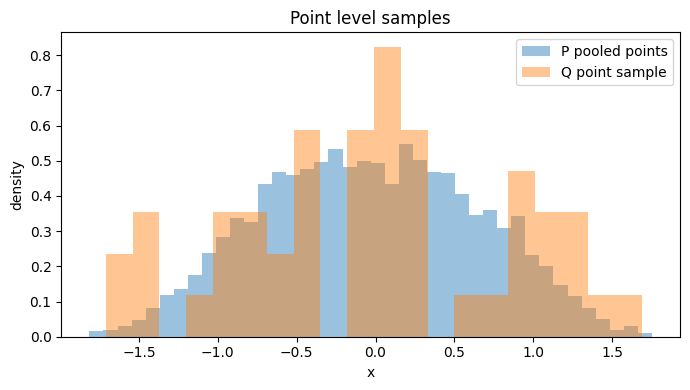

In [ ]:

plt.figure(figsize=(7, 4))
plt.hist(P_point, bins=40, density=True, alpha=0.45, label="P pooled points")
plt.hist(Q_point, bins=20, density=True, alpha=0.45, label="Q point sample")
plt.xlabel("x")
plt.ylabel("density")
plt.title("Point level samples")
plt.legend()
plt.tight_layout()
plt.show()



# Part 2. R statistic based on WSD

Here each bag is treated as one empirical distribution:

\[
P_{i,m}=\frac{1}{m}\sum_{j=1}^m \delta_{X_{i,j}},
\qquad
Q_{k,m}=\frac{1}{m}\sum_{\ell=1}^m \delta_{Y_{k,\ell}}.
\]

The reference population is fixed as

\[
\mathbf P_{n,m}=\{P_{1,m},\ldots,P_{n,m}\}.
\]

For each \(Q_{k,m}\), compute

\[
R(Q_{k,m};\mathbf P_{n,m})
=
\frac{1}{n}\sum_{i=1}^n
I\left\{
SD(P_{i,m};\mathbf P_{n,m})
\leq
SD(Q_{k,m};\mathbf P_{n,m})
\right\}.
\]

Then test whether the empirical distribution of these R values deviates from \(\mathrm{Unif}(0,1)\), using the chi squared goodness of fit test exactly as in the document example.


In [ ]:

def _sinkhorn_plan(wi, wj, C):
    wi = np.asarray(wi, dtype=np.float64)
    wj = np.asarray(wj, dtype=np.float64)
    C = np.asarray(C, dtype=np.float64)

    wi = wi / max(wi.sum(), EPS)
    wj = wj / max(wj.sum(), EPS)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        Pi = ot.sinkhorn(
            wi,
            wj,
            C,
            reg=SINKHORN_REG,
            method="sinkhorn_log",
            numItermax=SINKHORN_MAX_ITER,
            stopThr=SINKHORN_STOP_THR,
            warn=False,
        )

    return np.ascontiguousarray(Pi, dtype=np.float64)


def compute_WSD_X(X, labels, n_jobs=-1):
    if X.ndim != 4 or X.shape[-1] != 2:
        raise ValueError("X must be (M, n, d, 2)")
    M, n, d, _ = X.shape
    coords  = X[..., 0].astype(np.float64, copy=False)
    weights = X[:, :, 0, 1].astype(np.float64, copy=False)
    s = weights.sum(axis=1, keepdims=True); s[s <= 0] = 1.0
    weights = weights / s

    def _wsd_i(i):
        wi = np.ascontiguousarray(weights[i], dtype=np.float64)
        Xi = np.ascontiguousarray(coords[i],  dtype=np.float64)
        members = np.where(labels == labels[i])[0]
        members = members[members != i]
        if members.size == 0:
            return 1.0
        m_acc = np.zeros((n, d), dtype=np.float64)
        for j in members:
            wj = np.ascontiguousarray(weights[j], dtype=np.float64)
            Xj = np.ascontiguousarray(coords[j],  dtype=np.float64)
            C  = np.ascontiguousarray(ot.dist(Xi, Xj, metric="euclidean")**2, dtype=np.float64)
            Pi = _sinkhorn_plan(wi, wj, C)
            T_vals = (Pi @ Xj) / (wi[:, None] + EPS)
            W2 = np.sqrt((Pi * C).sum()) + EPS
            m_acc += (Xi - T_vals) / W2
        m_vec = m_acc / members.size
        norm_sq = np.sum(m_vec**2, axis=1)
        return 1.0 - np.sqrt(np.sum(wi * norm_sq))

    depths = Parallel(n_jobs=n_jobs)(delayed(_wsd_i)(i) for i in range(M))
    return np.array(depths)


def compute_WSD_Y(Y, X, n_jobs=1):
    if Y.ndim != 4 or X.ndim != 4 or Y.shape[-1] != 2 or X.shape[-1] != 2:
        raise ValueError("Y/X must be (M, n, d, 2)")
    if (Y.shape[1], Y.shape[2]) != (X.shape[1], X.shape[2]):
        raise ValueError("Y and X must share the same (n, d) for OT pairing.")
    My, n, d, _ = Y.shape
    Mx = X.shape[0]
    coordsY  = Y[..., 0].astype(np.float64, copy=False)
    coordsX  = X[..., 0].astype(np.float64, copy=False)
    weightsY = Y[:, :, 0, 1].astype(np.float64, copy=False)
    weightsX = X[:, :, 0, 1].astype(np.float64, copy=False)
    sY = weightsY.sum(axis=1, keepdims=True); sY[sY <= 0] = 1.0
    sX = weightsX.sum(axis=1, keepdims=True); sX[sX <= 0] = 1.0
    weightsY = weightsY / sY
    weightsX = weightsX / sX

    def _wsd_y(m):
        wy = np.ascontiguousarray(weightsY[m], dtype=np.float64)
        Yp = np.ascontiguousarray(coordsY[m],  dtype=np.float64)
        if Mx == 0:
            return 1.0
        m_acc = np.zeros((n, d), dtype=np.float64)
        for k in range(Mx):
            wk = np.ascontiguousarray(weightsX[k], dtype=np.float64)
            Xp = np.ascontiguousarray(coordsX[k],  dtype=np.float64)
            C  = np.ascontiguousarray(ot.dist(Yp, Xp, metric="euclidean")**2, dtype=np.float64)
            Pi = _sinkhorn_plan(wy, wk, C)
            T_vals = (Pi @ Xp) / (wy[:, None] + EPS)
            W2 = np.sqrt((Pi * C).sum()) + EPS
            m_acc += (Yp - T_vals) / W2
        m_vec = m_acc / Mx
        norm_sq = np.sum(m_vec**2, axis=1)
        return 1.0 - np.sqrt(np.sum(wy * norm_sq))

    depths = Parallel(n_jobs=n_jobs)(delayed(_wsd_y)(m) for m in range(My))
    return np.array(depths)


def bags_to_wsd_array(bags):
    bags = np.asarray(bags, dtype=np.float64)
    if bags.ndim != 2:
        raise ValueError("bags must have shape (M, m).")

    M, m = bags.shape
    X = np.zeros((M, m, 1, 2), dtype=np.float64)
    X[:, :, 0, 0] = bags
    X[:, :, 0, 1] = 1.0 / m
    return X


In [ ]:

X_wsd = bags_to_wsd_array(P_bags)
Y_wsd = bags_to_wsd_array(Q_bags)

labels_P = np.zeros(X_wsd.shape[0], dtype=int)

depths_P = compute_WSD_X(X_wsd, labels_P, n_jobs=-1)
depths_Q = compute_WSD_Y(Y_wsd, X_wsd, n_jobs=-1)

R_values = np.mean(depths_P[:, None] <= depths_Q[None, :], axis=0)

observed_counts, bin_edges = np.histogram(R_values, bins=R_BINS, range=(0.0, 1.0))
expected_counts = np.repeat(len(R_values) / R_BINS, R_BINS)
chi2_result = stats.chisquare(f_obs=observed_counts, f_exp=expected_counts)

print("depths_P summary:")
print({
    "min": float(np.min(depths_P)),
    "mean": float(np.mean(depths_P)),
    "max": float(np.max(depths_P)),
})

print("depths_Q summary:")
print({
    "min": float(np.min(depths_Q)),
    "mean": float(np.mean(depths_Q)),
    "max": float(np.max(depths_Q)),
})

print("R values summary:")
print({
    "min": float(np.min(R_values)),
    "mean": float(np.mean(R_values)),
    "max": float(np.max(R_values)),
})

print("Observed bin counts:")
print(observed_counts)

print("Chi squared goodness of fit test against Uniform(0, 1):")
print({
    "chi2_statistic": float(chi2_result.statistic),
    "p_value": float(chi2_result.pvalue),
})


KeyboardInterrupt: 

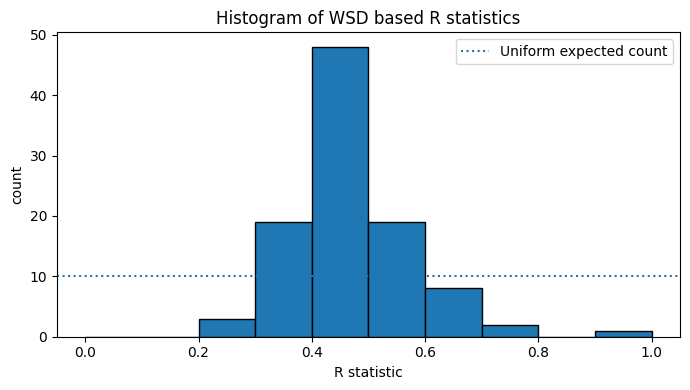

In [ ]:

plt.figure(figsize=(7, 4))
plt.hist(R_values, bins=R_BINS, range=(0.0, 1.0), edgecolor="black")
plt.axhline(len(R_values) / R_BINS, linestyle=":", label="Uniform expected count")
plt.xlabel("R statistic")
plt.ylabel("count")
plt.title("Histogram of WSD based R statistics")
plt.legend()
plt.tight_layout()
plt.show()


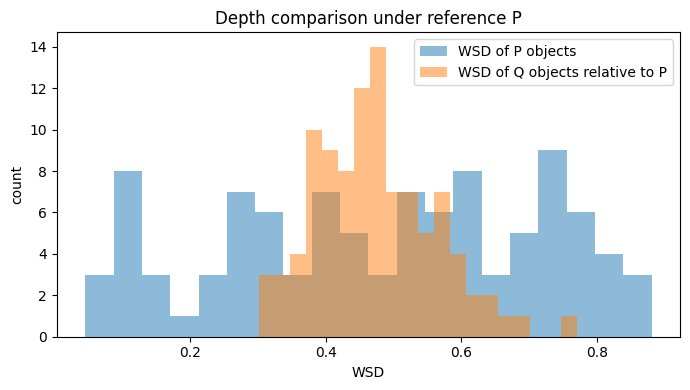

In [ ]:

plt.figure(figsize=(7, 4))
plt.hist(depths_P, bins=20, alpha=0.5, label="WSD of P objects")
plt.hist(depths_Q, bins=20, alpha=0.5, label="WSD of Q objects relative to P")
plt.xlabel("WSD")
plt.ylabel("count")
plt.title("Depth comparison under reference P")
plt.legend()
plt.tight_layout()
plt.show()



## Decision rule

For the point level tests, reject \(H_0:P_{\mathrm{point}}=Q_{\mathrm{point}}\) when the corresponding p value is less than the chosen level.

For the WSD R statistic test, reject

\[
H_0:\mathbf P=\mathbf Q
\]

when the chi squared goodness of fit p value for

\[
R(Q_{k,m};\mathbf P_{n,m})\sim \mathrm{Unif}(0,1)
\]

is less than the chosen level.



# Experiment 2. Annulus family versus eight fixed wedge rays

This experiment keeps the same structure as Experiment 1.

The point level part only uses energy distance and MMD, because KS is a one dimensional two sample test and is not used for these two dimensional samples.

The distribution level part uses the same WSD based R statistic. The reference population is always the empirical \(P\) population.


In [ ]:

# === Experiment 2 data generation ===
# P: annulus family with fixed area and increasing inner radius.
# Q: eight fixed wedge rays sampled together.
# Important: point-level Q is a single separate 50-point sample, not pooled Q_bags_2.
# Q_bags_2 are generated only for the distribution-level WSD R test.

N_P_2 = 100
N_Q_2 = 100
M_PER_DISTRIBUTION_2 = 50
R_IN_MIN_2 = 0.02
R_IN_MAX_2 = 1.0
AREA_CONST_2 = np.pi * (1.0**2 - R_IN_MIN_2**2)
N_RAYS_2 = 8
DELTA_THETA_2 = 2.0 * np.pi / N_RAYS_2
B_POINT_2 = 500
R_BINS_2 = 10

rng_exp2 = np.random.default_rng(SEED + 2026)


def sample_annulus(n, r_in, r_out, rng):
    theta = rng.uniform(0.0, 2.0 * np.pi, size=n)
    u = rng.uniform(0.0, 1.0, size=n)
    r = np.sqrt(r_in**2 + u * (r_out**2 - r_in**2))
    return np.column_stack([r * np.cos(theta), r * np.sin(theta)])


def annulus_outer_from_area(r_in, area):
    return np.sqrt(r_in**2 + area / np.pi)


def sample_annulus_family(n_bags=N_P_2, m=M_PER_DISTRIBUTION_2, r_in_min=R_IN_MIN_2, r_in_max=R_IN_MAX_2, area_const=AREA_CONST_2, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    r_in_grid = np.linspace(r_in_min, r_in_max, n_bags)
    bags = []
    info = []
    for r_in in r_in_grid:
        r_out = annulus_outer_from_area(r_in, area_const)
        bags.append(sample_annulus(m, r_in, r_out, rng))
        info.append((r_in, r_out))
    return np.asarray(bags, dtype=np.float64), np.asarray(info, dtype=np.float64)


def sample_fixed_eight_wedges(n, radial_pool, n_rays=N_RAYS_2, delta_theta=DELTA_THETA_2, rng=None, stratified=True):
    if rng is None:
        rng = np.random.default_rng(0)
    radial_pool = np.asarray(radial_pool, dtype=np.float64)
    if radial_pool.size == 0:
        raise ValueError("radial_pool must be nonempty.")

    base_angles = np.linspace(0.0, 2.0 * np.pi, n_rays, endpoint=False)

    if stratified:
        ray_idx = np.arange(n, dtype=int) % n_rays
        rng.shuffle(ray_idx)
    else:
        ray_idx = rng.integers(0, n_rays, size=n)

    theta = base_angles[ray_idx] + rng.uniform(-delta_theta / 2.0, delta_theta / 2.0, size=n)
    radial_idx = rng.integers(0, radial_pool.size, size=n)
    r = radial_pool[radial_idx]

    return np.column_stack([r * np.cos(theta), r * np.sin(theta)])


def sample_fixed_eight_wedge_family(n_bags=N_Q_2, m=M_PER_DISTRIBUTION_2, radial_pool=None, n_rays=N_RAYS_2, delta_theta=DELTA_THETA_2, rng=None, stratified=True):
    if rng is None:
        rng = np.random.default_rng(0)
    if radial_pool is None or len(radial_pool) == 0:
        raise ValueError("radial_pool must be a nonempty array sampled from the P pooled radial marginal.")
    bags = []
    for _ in range(n_bags):
        bags.append(
            sample_fixed_eight_wedges(
                n=m,
                radial_pool=radial_pool,
                n_rays=n_rays,
                delta_theta=delta_theta,
                rng=rng,
                stratified=stratified,
            )
        )
    return np.asarray(bags, dtype=np.float64)


# P point-level sample is the pooled point sample from P bags, matching Experiment 1.
P_bags_2, P_ring_info_2 = sample_annulus_family(rng=rng_exp2)
P_point_2 = P_bags_2.reshape(-1, 2)
P_radial_pool_2 = np.linalg.norm(P_point_2, axis=1)

# Point-level Q sample is one separate 50-point sample, not a concatenation of Q_bags_2.
Q_point_2 = sample_fixed_eight_wedges(
    n=M_PER_DISTRIBUTION_2,
    radial_pool=P_radial_pool_2,
    n_rays=N_RAYS_2,
    delta_theta=DELTA_THETA_2,
    rng=rng_exp2,
    stratified=True,
)

# Distribution-level Q objects for the WSD R test.
Q_bags_2 = sample_fixed_eight_wedge_family(
    n_bags=N_Q_2,
    m=M_PER_DISTRIBUTION_2,
    radial_pool=P_radial_pool_2,
    n_rays=N_RAYS_2,
    delta_theta=DELTA_THETA_2,
    rng=rng_exp2,
    stratified=True,
)

print(f"Experiment 2 P_bags shape: {P_bags_2.shape}")
print(f"Experiment 2 Q_bags shape for R test: {Q_bags_2.shape}")
print(f"Experiment 2 P point-level sample shape: {P_point_2.shape}")
print(f"Experiment 2 Q point-level sample shape: {Q_point_2.shape}")
print(f"Annulus inner radius range: {P_ring_info_2[:, 0].min():.4f} to {P_ring_info_2[:, 0].max():.4f}")
print(f"Annulus outer radius range: {P_ring_info_2[:, 1].min():.4f} to {P_ring_info_2[:, 1].max():.4f}")
print(f"Fixed annulus area: {AREA_CONST_2:.4f}")
print(f"Q: {N_RAYS_2} fixed wedges sampled together")
print(f"Q wedge width: {DELTA_THETA_2:.4f} rad, {np.degrees(DELTA_THETA_2):.2f} degrees")
print(f"One Q sample angular coverage: {N_RAYS_2 * DELTA_THETA_2 / (2.0 * np.pi):.2%}")


Experiment 2 P_bags shape: (100, 50, 2)
Experiment 2 Q_bags shape for R test: (100, 50, 2)
Experiment 2 P point-level sample shape: (5000, 2)
Experiment 2 Q point-level sample shape: (50, 2)
Annulus inner radius range: 0.0200 to 1.0000
Annulus outer radius range: 1.0000 to 1.4141
Fixed annulus area: 3.1403
Q: 8 fixed wedges sampled together
Q wedge width: 0.7854 rad, 45.00 degrees
One Q sample angular coverage: 100.00%


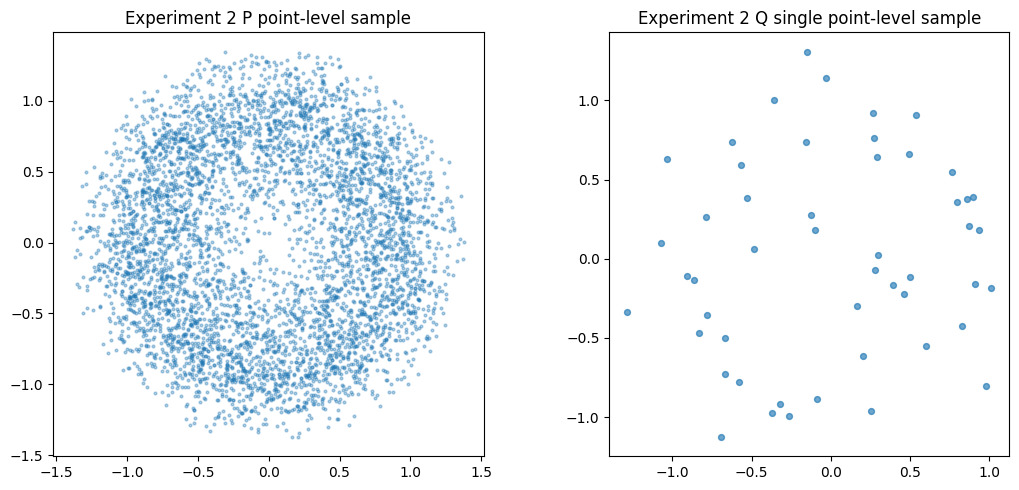

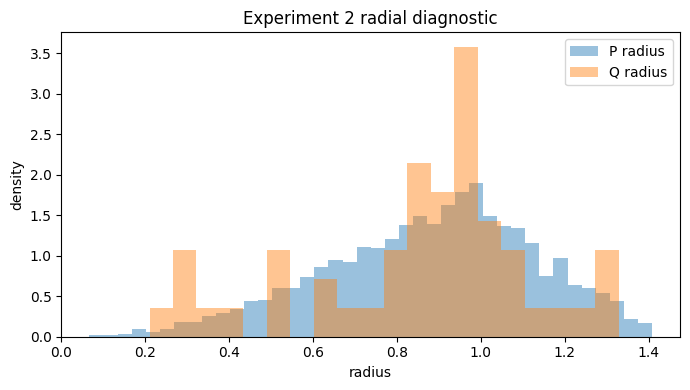

{'test': 'Energy distance', 'statistic': 0.008079972117044143, 'p_value': 0.9620758483033932}
{'test': 'MMD', 'statistic': -0.006473412340753271, 'p_value': 0.9481037924151696, 'sigma': 1.1827644159973132}


In [ ]:

# === Experiment 2 point level tests ===
# KS is intentionally omitted because these are two dimensional samples.
# Q_point_2 is a single 50-point sample. It is not Q_bags_2.reshape(-1, 2).

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].scatter(P_point_2[:, 0], P_point_2[:, 1], s=4, alpha=0.35)
axes[0].set_title("Experiment 2 P point-level sample")
axes[0].set_aspect("equal")

axes[1].scatter(Q_point_2[:, 0], Q_point_2[:, 1], s=18, alpha=0.65)
axes[1].set_title("Experiment 2 Q single point-level sample")
axes[1].set_aspect("equal")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(np.linalg.norm(P_point_2, axis=1), bins=40, density=True, alpha=0.45, label="P radius")
plt.hist(np.linalg.norm(Q_point_2, axis=1), bins=20, density=True, alpha=0.45, label="Q radius")
plt.xlabel("radius")
plt.ylabel("density")
plt.title("Experiment 2 radial diagnostic")
plt.legend()
plt.tight_layout()
plt.show()


def energy_permutation_test_2d(X, Y, B=B_POINT_2, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    Z = np.vstack([X, Y])
    m = X.shape[0]
    N = Z.shape[0]

    D = squareform(pdist(Z, metric="euclidean"))
    idx_x = np.arange(m)
    idx_y = np.arange(m, N)
    obs = energy_statistic_from_distance(D, idx_x, idx_y)

    perm_stats = np.empty(B, dtype=float)
    for b in range(B):
        perm = rng.permutation(N)
        perm_stats[b] = energy_statistic_from_distance(D, perm[:m], perm[m:])

    p_value = (1.0 + np.sum(perm_stats >= obs)) / (B + 1.0)
    del D
    gc.collect()

    return {
        "test": "Energy distance",
        "statistic": float(obs),
        "p_value": float(p_value),
    }


def median_heuristic_sigma_2d(Z):
    Z = np.asarray(Z, dtype=np.float64)
    distances = pdist(Z, metric="euclidean")
    positive = distances[distances > 0]
    if positive.size == 0:
        return 1.0
    return float(np.median(positive))


def mmd_permutation_test_2d(X, Y, B=B_POINT_2, rng=None, sigma=None):
    if rng is None:
        rng = np.random.default_rng()

    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    Z = np.vstack([X, Y])
    m = X.shape[0]
    N = Z.shape[0]

    if sigma is None:
        sigma = median_heuristic_sigma_2d(Z)

    sqD = squareform(pdist(Z, metric="sqeuclidean"))
    K = np.exp(-sqD / (2.0 * sigma ** 2))

    idx_x = np.arange(m)
    idx_y = np.arange(m, N)
    obs = mmd2_unbiased_from_kernel(K, idx_x, idx_y)

    perm_stats = np.empty(B, dtype=float)
    for b in range(B):
        perm = rng.permutation(N)
        perm_stats[b] = mmd2_unbiased_from_kernel(K, perm[:m], perm[m:])

    p_value = (1.0 + np.sum(perm_stats >= obs)) / (B + 1.0)
    del sqD, K
    gc.collect()

    return {
        "test": "MMD",
        "statistic": float(obs),
        "p_value": float(p_value),
        "sigma": float(sigma),
    }


energy_result_2 = energy_permutation_test_2d(P_point_2, Q_point_2, B=B_POINT_2, rng=rng_exp2)
mmd_result_2 = mmd_permutation_test_2d(P_point_2, Q_point_2, B=B_POINT_2, rng=rng_exp2)

point_results_2 = [energy_result_2, mmd_result_2]
for result in point_results_2:
    print(result)



## Experiment 2 R statistic based on WSD

Each two dimensional bag is treated as one empirical distribution. The reference is fixed as the empirical \(P\) population.


In [ ]:

# === Experiment 2 WSD R test ===
# This uses the same compute_WSD_X and compute_WSD_Y functions defined above.


def bags_to_wsd_array_2d(bags):
    bags = np.asarray(bags, dtype=np.float64)
    if bags.ndim != 3 or bags.shape[-1] != 2:
        raise ValueError("bags must have shape (M, m, 2).")

    M, m, d = bags.shape
    X = np.zeros((M, m, d, 2), dtype=np.float64)
    X[..., 0] = bags
    X[:, :, 0, 1] = 1.0 / m
    return X


X_wsd_2 = bags_to_wsd_array_2d(P_bags_2)
Y_wsd_2 = bags_to_wsd_array_2d(Q_bags_2)

labels_P_2 = np.zeros(X_wsd_2.shape[0], dtype=int)

depths_P_2 = compute_WSD_X(X_wsd_2, labels_P_2, n_jobs=-1)
depths_Q_2 = compute_WSD_Y(Y_wsd_2, X_wsd_2, n_jobs=-1)

R_values_2 = np.mean(depths_P_2[:, None] <= depths_Q_2[None, :], axis=0)

observed_counts_2, bin_edges_2 = np.histogram(R_values_2, bins=R_BINS_2, range=(0.0, 1.0))
expected_counts_2 = np.repeat(len(R_values_2) / R_BINS_2, R_BINS_2)
chi2_result_2 = stats.chisquare(f_obs=observed_counts_2, f_exp=expected_counts_2)

print("Experiment 2 depths_P summary:")
print({
    "min": float(np.min(depths_P_2)),
    "mean": float(np.mean(depths_P_2)),
    "max": float(np.max(depths_P_2)),
})

print("Experiment 2 depths_Q summary:")
print({
    "min": float(np.min(depths_Q_2)),
    "mean": float(np.mean(depths_Q_2)),
    "max": float(np.max(depths_Q_2)),
})

print("Experiment 2 R values summary:")
print({
    "min": float(np.min(R_values_2)),
    "mean": float(np.mean(R_values_2)),
    "max": float(np.max(R_values_2)),
})

print("Experiment 2 observed bin counts:")
print(observed_counts_2)

print("Experiment 2 chi squared goodness of fit test against Uniform(0, 1):")
print({
    "chi2_statistic": float(chi2_result_2.statistic),
    "p_value": float(chi2_result_2.pvalue),
})


Experiment 2 depths_P summary:
{'min': 0.1857626332765997, 'mean': 0.46735560139853377, 'max': 0.6974397489694586}
Experiment 2 depths_Q summary:
{'min': 0.4738542801501745, 'mean': 0.5619414724670105, 'max': 0.6519537653744513}
Experiment 2 R values summary:
{'min': 0.46, 'mean': 0.7640999999999998, 'max': 0.97}
Experiment 2 observed bin counts:
[ 0  0  0  0  1  4 17 48 18 12]
Experiment 2 chi squared goodness of fit test against Uniform(0, 1):
{'chi2_statistic': 207.8, 'p_value': 7.656804770687801e-40}


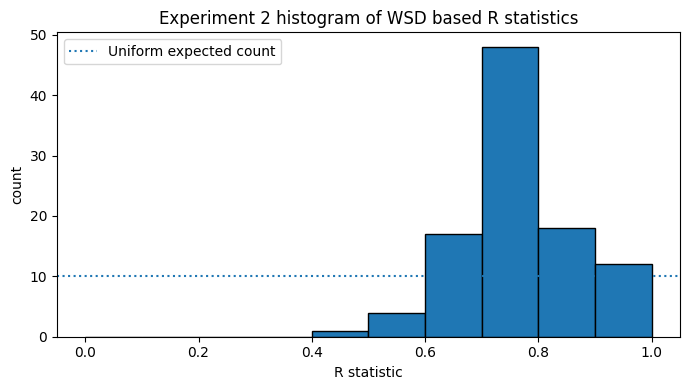

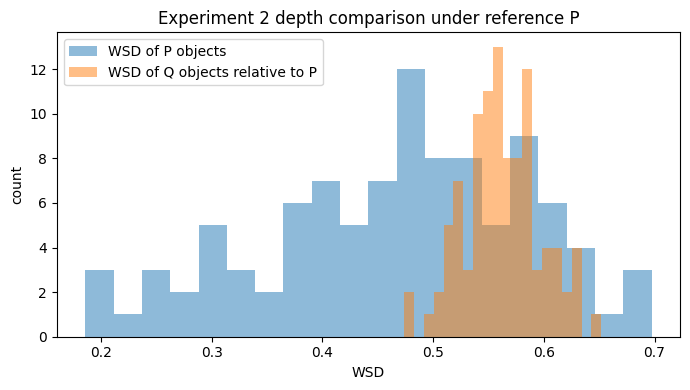

In [ ]:

plt.figure(figsize=(7, 4))
plt.hist(R_values_2, bins=R_BINS_2, range=(0.0, 1.0), edgecolor="black")
plt.axhline(len(R_values_2) / R_BINS_2, linestyle=":", label="Uniform expected count")
plt.xlabel("R statistic")
plt.ylabel("count")
plt.title("Experiment 2 histogram of WSD based R statistics")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(depths_P_2, bins=20, alpha=0.5, label="WSD of P objects")
plt.hist(depths_Q_2, bins=20, alpha=0.5, label="WSD of Q objects relative to P")
plt.xlabel("WSD")
plt.ylabel("count")
plt.title("Experiment 2 depth comparison under reference P")
plt.legend()
plt.tight_layout()
plt.show()


## Experiment 2 decision rule

For the two dimensional point level comparison, only energy distance and MMD are reported.

For the distribution level comparison, reject

\[
H_0:\mathbf P=\mathbf Q
\]

when the chi squared goodness of fit p value for

\[
R(Q_{k,m};\mathbf P_{n,m})\sim \mathrm{Unif}(0,1)
\]

is less than the chosen level.


<!-- MC_REPLICATION_BLOCK_v1 -->
# Monte Carlo replication study (50 reps per scenario)

We repeat each two sample test on multiple resamples of $Q$ to obtain
a distribution of p-values rather than a single realization.

* **Alternative regime**: keep the reference $\mathbf P_{n,m}$ and its WSD depths
  fixed; resample $Q$ from the contrast distribution `N_REPS` times. Power
  is the fraction of p-values below $\alpha=0.05$.
* **Null regime**: resample a fresh $P'\sim P$ population and treat it as
  $Q$, comparing to the same fixed reference. Should fail to reject; we
  report the empirical Type I error.

All four methods (KS, energy, MMD, WSD $R$-test) are evaluated. KS is only
applicable in Scenario 1 (1D).

In [ ]:
# MC_REPLICATION_BLOCK_v1: config + helpers
N_REPS = 20  # seeds will be 0..N_REPS-1
ALPHA = 0.05

def summarize_pvals(pvals):
    p = np.asarray(pvals, dtype=float)
    if p.size == 0:
        return {'n': 0, 'median': float('nan'), 'mean': float('nan'),
                'std': float('nan'), 'power': float('nan')}
    return {
        'n': int(p.size),
        'median': float(np.median(p)),
        'mean': float(np.mean(p)),
        'std': float(np.std(p, ddof=1)) if p.size > 1 else 0.0,
        'power': float(np.mean(p < ALPHA)),
    }

def wsd_rtest_pvalue(Q_bags_array, X_wsd_ref, depths_P_ref, ndim,
                     n_bins=R_BINS, n_jobs=-1):
    if ndim == 1:
        Y_wsd_local = bags_to_wsd_array(Q_bags_array)
    elif ndim == 2:
        Y_wsd_local = bags_to_wsd_array_2d(Q_bags_array)
    else:
        raise ValueError('ndim must be 1 or 2')
    depths_Q_local = compute_WSD_Y(Y_wsd_local, X_wsd_ref, n_jobs=n_jobs)
    R_local = np.mean(depths_P_ref[:, None] <= depths_Q_local[None, :], axis=0)
    obs_counts, _ = np.histogram(R_local, bins=n_bins, range=(0.0, 1.0))
    exp_counts = np.repeat(len(R_local) / n_bins, n_bins)
    chi2_local = stats.chisquare(f_obs=obs_counts, f_exp=exp_counts)
    return float(chi2_local.pvalue)

print(f'Will run N_REPS={N_REPS} replications per (scenario, regime).')


Will run N_REPS=20 replications per (scenario, regime).


In [ ]:
# MC_REPLICATION_BLOCK_v1: Scenario 1 alternative (Q vs P-reference), 50 reps
import time as _time
pvals_s1_alt = {'KS': [], 'Energy': [], 'MMD': [], 'WSD R-test': []}
_t0 = _time.time()
for r in range(N_REPS):
    rng_r = np.random.default_rng(r)
    Q_bags_rep = generate_q_bags(rng_r, q_support, q_masses)
    Q_point_rep = Q_bags_rep[0].copy()
    pvals_s1_alt['KS'].append(
        ks_two_sample_test(P_point, Q_point_rep)['p_value'])
    pvals_s1_alt['Energy'].append(
        energy_permutation_test(P_point, Q_point_rep, B=B_POINT, rng=rng_r)['p_value'])
    pvals_s1_alt['MMD'].append(
        mmd_permutation_test(P_point, Q_point_rep, B=B_POINT, rng=rng_r)['p_value'])
    p_R = wsd_rtest_pvalue(Q_bags_rep, X_wsd, depths_P, ndim=1)
    pvals_s1_alt['WSD R-test'].append(p_R)
    print(f'  S1 alt rep {r+1:2d}/{N_REPS}  '
          f'KS={pvals_s1_alt["KS"][-1]:.3e}  '
          f'Energy={pvals_s1_alt["Energy"][-1]:.3e}  '
          f'MMD={pvals_s1_alt["MMD"][-1]:.3e}  '
          f'WSD={p_R:.3e}  '
          f'({_time.time()-_t0:.0f}s)')
print('\n[S1 alt] summary:')
for name, pv in pvals_s1_alt.items():
    print(f'  {name:11s}', summarize_pvals(pv))


  S1 alt rep  1/20  KS=3.122e-01  Energy=7.585e-02  MMD=5.988e-02  WSD=1.514e-58  (482s)
  S1 alt rep  2/20  KS=4.384e-01  Energy=2.475e-01  MMD=3.673e-01  WSD=1.947e-45  (946s)
  S1 alt rep  3/20  KS=9.270e-01  Energy=7.824e-01  MMD=7.046e-01  WSD=1.106e-63  (1416s)
  S1 alt rep  4/20  KS=4.119e-01  Energy=3.932e-01  MMD=2.814e-01  WSD=8.315e-70  (1877s)
  S1 alt rep  5/20  KS=2.901e-02  Energy=3.992e-03  MMD=2.794e-02  WSD=4.158e-64  (2337s)
  S1 alt rep  6/20  KS=2.071e-01  Energy=8.982e-02  MMD=5.389e-02  WSD=2.812e-52  (2769s)
  S1 alt rep  7/20  KS=1.423e-01  Energy=8.383e-02  MMD=7.784e-02  WSD=9.290e-54  (3191s)
  S1 alt rep  8/20  KS=6.403e-01  Energy=2.136e-01  MMD=1.457e-01  WSD=3.203e-48  (3628s)
  S1 alt rep  9/20  KS=1.135e-01  Energy=1.357e-01  MMD=8.583e-02  WSD=4.287e-40  (4080s)
  S1 alt rep 10/20  KS=1.119e-02  Energy=1.996e-03  MMD=3.992e-03  WSD=3.533e-40  (4547s)
  S1 alt rep 11/20  KS=3.190e-01  Energy=2.854e-01  MMD=2.255e-01  WSD=1.488e-56  (5024s)
  S1 alt rep

In [ ]:
# MC_REPLICATION_BLOCK_v1: Scenario 1 null (P' ~ P, treated as Q), 50 reps
import time as _time
pvals_s1_null = {'KS': [], 'Energy': [], 'MMD': [], 'WSD R-test': []}
_t0 = _time.time()
for r in range(N_REPS):
    rng_r = np.random.default_rng(r)
    Pprime_bags, _ = generate_p_bags(rng_r)
    Q_point_rep = Pprime_bags[0].copy()
    pvals_s1_null['KS'].append(
        ks_two_sample_test(P_point, Q_point_rep)['p_value'])
    pvals_s1_null['Energy'].append(
        energy_permutation_test(P_point, Q_point_rep, B=B_POINT, rng=rng_r)['p_value'])
    pvals_s1_null['MMD'].append(
        mmd_permutation_test(P_point, Q_point_rep, B=B_POINT, rng=rng_r)['p_value'])
    p_R = wsd_rtest_pvalue(Pprime_bags, X_wsd, depths_P, ndim=1)
    pvals_s1_null['WSD R-test'].append(p_R)
    print(f'  S1 null rep {r+1:2d}/{N_REPS}  '
          f'KS={pvals_s1_null["KS"][-1]:.3e}  '
          f'Energy={pvals_s1_null["Energy"][-1]:.3e}  '
          f'MMD={pvals_s1_null["MMD"][-1]:.3e}  '
          f'WSD={p_R:.3e}  '
          f'({_time.time()-_t0:.0f}s)')
print('\n[S1 null] summary:')
for name, pv in pvals_s1_null.items():
    print(f'  {name:11s}', summarize_pvals(pv))


  S1 null rep  1/20  KS=1.432e-01  Energy=4.192e-02  MMD=5.190e-02  WSD=2.971e-03  (424s)
  S1 null rep  2/20  KS=3.543e-01  Energy=2.974e-01  MMD=1.357e-01  WSD=3.517e-02  (858s)
  S1 null rep  3/20  KS=9.622e-02  Energy=4.990e-02  MMD=1.377e-01  WSD=1.024e-02  (1262s)
  S1 null rep  4/20  KS=4.754e-08  Energy=1.996e-03  MMD=1.996e-03  WSD=2.622e-01  (1502s)
  S1 null rep  5/20  KS=7.517e-10  Energy=1.996e-03  MMD=1.996e-03  WSD=1.265e-02  (1764s)
  S1 null rep  6/20  KS=4.358e-03  Energy=3.992e-03  MMD=1.996e-03  WSD=8.559e-02  (2282s)
  S1 null rep  7/20  KS=1.264e-01  Energy=7.984e-02  MMD=1.537e-01  WSD=6.990e-06  (2661s)
  S1 null rep  8/20  KS=3.313e-03  Energy=1.996e-03  MMD=5.988e-03  WSD=2.368e-01  (3058s)
  S1 null rep  9/20  KS=3.207e-01  Energy=3.633e-01  MMD=4.750e-01  WSD=2.133e-01  (3444s)
  S1 null rep 10/20  KS=2.253e-05  Energy=1.996e-03  MMD=1.996e-03  WSD=6.688e-02  (3852s)
  S1 null rep 11/20  KS=3.147e-10  Energy=1.996e-03  MMD=1.996e-03  WSD=1.088e-01  (4249s)
 

In [ ]:
# MC_REPLICATION_BLOCK_v1: Scenario 2 alternative (Q vs P-reference), 50 reps
import time as _time
pvals_s2_alt = {'Energy': [], 'MMD': [], 'WSD R-test': []}
_t0 = _time.time()
for r in range(N_REPS):
    rng_r = np.random.default_rng(r)
    Q_bags_rep_2 = sample_fixed_eight_wedge_family(
        n_bags=N_Q_2, m=M_PER_DISTRIBUTION_2,
        radial_pool=P_radial_pool_2,
        n_rays=N_RAYS_2, delta_theta=DELTA_THETA_2,
        rng=rng_r, stratified=True)
    Q_point_rep_2 = sample_fixed_eight_wedges(
        n=M_PER_DISTRIBUTION_2, radial_pool=P_radial_pool_2,
        n_rays=N_RAYS_2, delta_theta=DELTA_THETA_2,
        rng=rng_r, stratified=True)
    pvals_s2_alt['Energy'].append(
        energy_permutation_test_2d(P_point_2, Q_point_rep_2, B=B_POINT_2, rng=rng_r)['p_value'])
    pvals_s2_alt['MMD'].append(
        mmd_permutation_test_2d(P_point_2, Q_point_rep_2, B=B_POINT_2, rng=rng_r)['p_value'])
    p_R = wsd_rtest_pvalue(Q_bags_rep_2, X_wsd_2, depths_P_2, ndim=2)
    pvals_s2_alt['WSD R-test'].append(p_R)
    print(f'  S2 alt rep {r+1:2d}/{N_REPS}  '
          f'Energy={pvals_s2_alt["Energy"][-1]:.3e}  '
          f'MMD={pvals_s2_alt["MMD"][-1]:.3e}  '
          f'WSD={p_R:.3e}  '
          f'({_time.time()-_t0:.0f}s)')
print('\n[S2 alt] summary:')
for name, pv in pvals_s2_alt.items():
    print(f'  {name:11s}', summarize_pvals(pv))


In [ ]:
# MC_REPLICATION_BLOCK_v1: Scenario 2 null (P' ~ P annulus family, treated as Q), 50 reps
import time as _time
pvals_s2_null = {'Energy': [], 'MMD': [], 'WSD R-test': []}
_t0 = _time.time()
for r in range(N_REPS):
    rng_r = np.random.default_rng(r)
    Pprime_bags_2, _ = sample_annulus_family(rng=rng_r)
    Q_point_rep_2 = Pprime_bags_2[0].copy()
    pvals_s2_null['Energy'].append(
        energy_permutation_test_2d(P_point_2, Q_point_rep_2, B=B_POINT_2, rng=rng_r)['p_value'])
    pvals_s2_null['MMD'].append(
        mmd_permutation_test_2d(P_point_2, Q_point_rep_2, B=B_POINT_2, rng=rng_r)['p_value'])
    p_R = wsd_rtest_pvalue(Pprime_bags_2, X_wsd_2, depths_P_2, ndim=2)
    pvals_s2_null['WSD R-test'].append(p_R)
    print(f'  S2 null rep {r+1:2d}/{N_REPS}  '
          f'Energy={pvals_s2_null["Energy"][-1]:.3e}  '
          f'MMD={pvals_s2_null["MMD"][-1]:.3e}  '
          f'WSD={p_R:.3e}  '
          f'({_time.time()-_t0:.0f}s)')
print('\n[S2 null] summary:')
for name, pv in pvals_s2_null.items():
    print(f'  {name:11s}', summarize_pvals(pv))


In [ ]:
# MC_REPLICATION_BLOCK_v1: aggregate tables + LaTeX printout
all_results = {
    'S1 alt': pvals_s1_alt, 'S1 null': pvals_s1_null,
    'S2 alt': pvals_s2_alt, 'S2 null': pvals_s2_null,
}

print('=' * 78)
print(f'Summary across N_REPS={N_REPS} reps at alpha={ALPHA}')
print('=' * 78)
method_order = ['KS', 'Energy', 'MMD', 'WSD R-test']
header = f'{"scenario":10s}  {"method":11s}  {"n":>3s}  {"median p":>11s}  '\
         f'{"mean p":>11s}  {"std p":>11s}  {"power/TypeI":>11s}'
print(header)
print('-' * len(header))
for tag, dct in all_results.items():
    for m in method_order:
        if m not in dct:
            continue
        s = summarize_pvals(dct[m])
        print(f'{tag:10s}  {m:11s}  {s["n"]:3d}  {s["median"]:11.3e}  '
              f'{s["mean"]:11.3e}  {s["std"]:11.3e}  {s["power"]:11.3f}')

# save for later use
_payload = {}
for tag, dct in all_results.items():
    for m, pv in dct.items():
        key = f'{tag.replace(" ", "_")}__{m.replace(" ", "_").replace("-", "_")}'
        _payload[key] = np.asarray(pv, dtype=float)
_payload['meta'] = np.array([N_REPS, ALPHA])
np.savez('mc_results.npz', **_payload)
print(f'\nSaved {len(_payload)} arrays to mc_results.npz')

# LaTeX table block
def _fmt(method, dct, regime):
    if method not in dct or len(dct[method]) == 0:
        return r'n/a'
    s = summarize_pvals(dct[method])
    if regime == 'alt':
        return f'{s["power"]:.2f} ({s["median"]:.2e})'
    return f'{s["power"]:.2f} ({s["median"]:.2f})'

tex = []
tex.append('% Auto-generated by the MC replication cells')
tex.append(rf'% N_REPS={N_REPS}, alpha={ALPHA}')
tex.append(r'\begin{table}[H]\centering')
tex.append(rf'\caption{{Empirical power under the alternative '
           rf'(fraction of $p<{ALPHA}$) over $N_{{\mathrm{{rep}}}}={N_REPS}$ '
           r'replications; median $p$-value in parentheses. '
           r'$\mathbf P_{n,m}$ and its depths held fixed across reps.}')
tex.append(r'\label{tab:two_sample_power}')
tex.append(r'\begin{tabular}{lcccc}\toprule')
tex.append(r' & KS & Energy & MMD & WSD $R$-test \\\midrule')
tex.append('Shifted uniforms vs.\\ marginal disc.\\ '
           f'& {_fmt("KS", pvals_s1_alt, "alt")} '
           f'& {_fmt("Energy", pvals_s1_alt, "alt")} '
           f'& {_fmt("MMD", pvals_s1_alt, "alt")} '
           f'& {_fmt("WSD R-test", pvals_s1_alt, "alt")} \\\\')
tex.append('Annuli vs.\\ eight wedge rays '
           f'& n/a '
           f'& {_fmt("Energy", pvals_s2_alt, "alt")} '
           f'& {_fmt("MMD", pvals_s2_alt, "alt")} '
           f'& {_fmt("WSD R-test", pvals_s2_alt, "alt")} \\\\')
tex.append(r'\bottomrule\end{tabular}\end{table}')
tex.append('')
tex.append(r'\begin{table}[H]\centering')
tex.append(rf'\caption{{Empirical Type I error under the null '
           rf"$P'\sim P$ at $\alpha={ALPHA}$ "
           r'(median $p$-value in parentheses); ideal value is $\alpha$.}')
tex.append(r'\label{tab:two_sample_typeI}')
tex.append(r'\begin{tabular}{lcccc}\toprule')
tex.append(r' & KS & Energy & MMD & WSD $R$-test \\\midrule')
tex.append('Shifted uniforms vs.\\ marginal disc.\\ '
           f'& {_fmt("KS", pvals_s1_null, "null")} '
           f'& {_fmt("Energy", pvals_s1_null, "null")} '
           f'& {_fmt("MMD", pvals_s1_null, "null")} '
           f'& {_fmt("WSD R-test", pvals_s1_null, "null")} \\\\')
tex.append('Annuli vs.\\ eight wedge rays '
           f'& n/a '
           f'& {_fmt("Energy", pvals_s2_null, "null")} '
           f'& {_fmt("MMD", pvals_s2_null, "null")} '
           f'& {_fmt("WSD R-test", pvals_s2_null, "null")} \\\\')
tex.append(r'\bottomrule\end{tabular}\end{table}')
tex_block = '\n'.join(tex)
print('\n' + '=' * 78)
print('LaTeX block (also written to mc_tables.tex):')
print('=' * 78)
print(tex_block)
with open('mc_tables.tex', 'w') as _f:
    _f.write(tex_block)


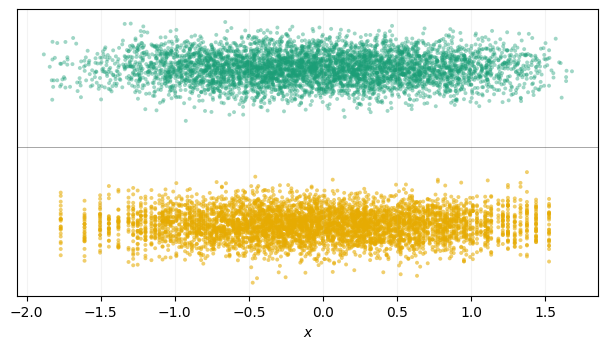

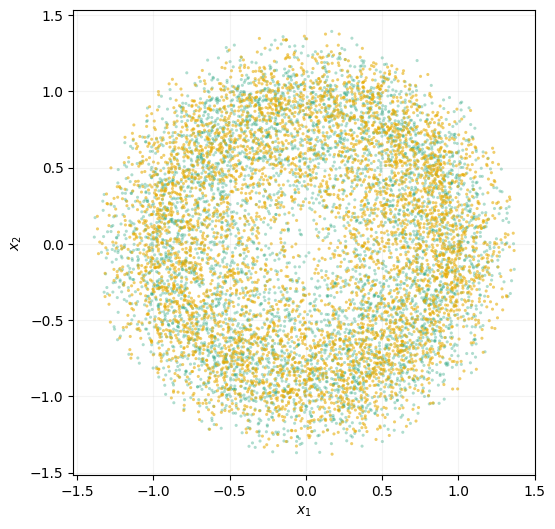

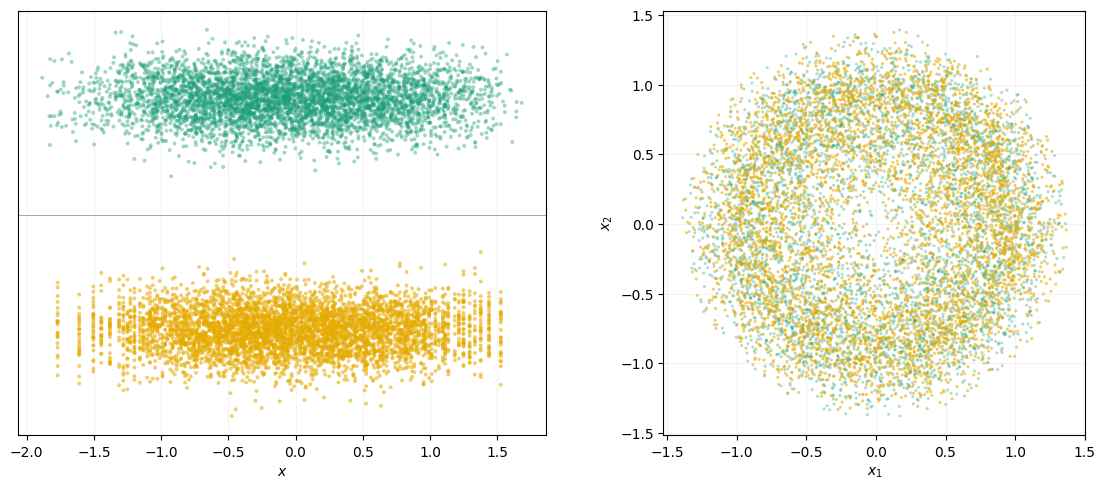

(<Figure size 1160x500 with 2 Axes>,
 array([<Axes: xlabel='$x$'>, <Axes: xlabel='$x_1$', ylabel='$x_2$'>],
       dtype=object))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


GREEN = "#1b9e77"
YELLOW = "#e6ab02"

N_BAGS = 100
M_POINTS = 50
SEED = 123


def sample_shifted_uniform_bags(
    n_bags=100,
    m_points=50,
    seed=123
):
    rng = np.random.default_rng(seed)

    centers = rng.triangular(left=-1.0, mode=0.0, right=1.0, size=n_bags)

    bags = []
    for c in centers:
        pts = rng.uniform(c - 1.0, c + 1.0, size=m_points)
        bags.append(pts[:, None])

    return np.asarray(bags), centers


def sample_marginal_grid_from_empirical_p(
    P_bags,
    n_support=200
):
    P_points = P_bags.reshape(-1)
    probs = (np.arange(n_support) + 0.5) / n_support
    support = np.quantile(P_points, probs)
    weights = np.ones(n_support) / n_support
    return support, weights


def sample_discrete_q_bags_1d(
    n_bags=100,
    m_points=50,
    support=None,
    weights=None,
    seed=456
):
    rng = np.random.default_rng(seed)

    support = np.asarray(support)
    weights = np.asarray(weights)
    weights = weights / weights.sum()

    bags = []
    for _ in range(n_bags):
        idx = rng.choice(len(support), size=m_points, replace=True, p=weights)
        pts = support[idx]
        bags.append(pts[:, None])

    return np.asarray(bags)


def sample_annulus(
    n,
    r_in,
    r_out,
    rng
):
    theta = rng.uniform(0.0, 2.0 * np.pi, size=n)
    u = rng.uniform(0.0, 1.0, size=n)
    r = np.sqrt(r_in**2 + u * (r_out**2 - r_in**2))
    return np.column_stack([r * np.cos(theta), r * np.sin(theta)])


def annulus_outer_from_area(
    r_in,
    area
):
    return np.sqrt(r_in**2 + area / np.pi)


def sample_annulus_family(
    n_bags=100,
    m_points=50,
    r_in_min=0.02,
    r_in_max=1.0,
    area_const=None,
    seed=789
):
    rng = np.random.default_rng(seed)

    if area_const is None:
        area_const = np.pi * (1.0**2 - r_in_min**2)

    r_in_grid = np.linspace(r_in_min, r_in_max, n_bags)

    bags = []
    info = []

    for r_in in r_in_grid:
        r_out = annulus_outer_from_area(r_in, area_const)
        pts = sample_annulus(m_points, r_in, r_out, rng)
        bags.append(pts)
        info.append((r_in, r_out))

    return np.asarray(bags), np.asarray(info), area_const


def sample_fixed_wedge_rays(
    n,
    radial_pool,
    n_rays=8,
    delta_theta=None,
    rng=None,
    stratified=True
):
    if rng is None:
        rng = np.random.default_rng(0)

    if delta_theta is None:
        delta_theta = 2.0 * np.pi / n_rays

    radial_pool = np.asarray(radial_pool)
    base_angles = np.linspace(0.0, 2.0 * np.pi, n_rays, endpoint=False)

    if stratified:
        counts = np.full(n_rays, n // n_rays, dtype=int)
        counts[: n % n_rays] += 1
        ray_idx = np.concatenate([
            np.full(counts[k], k, dtype=int)
            for k in range(n_rays)
        ])
        rng.shuffle(ray_idx)
    else:
        ray_idx = rng.integers(0, n_rays, size=n)

    base = base_angles[ray_idx]
    angle_off = rng.uniform(-delta_theta / 2.0, delta_theta / 2.0, size=n)
    theta = base + angle_off

    radial_idx = rng.integers(0, len(radial_pool), size=n)
    r = radial_pool[radial_idx]

    return np.column_stack([r * np.cos(theta), r * np.sin(theta)])


def sample_fixed_wedge_ray_family(
    n_bags=100,
    m_points=50,
    radial_pool=None,
    n_rays=8,
    delta_theta=None,
    seed=987
):
    rng = np.random.default_rng(seed)

    if radial_pool is None:
        raise ValueError("radial_pool must be provided.")

    bags = []

    for _ in range(n_bags):
        pts = sample_fixed_wedge_rays(
            n=m_points,
            radial_pool=radial_pool,
            n_rays=n_rays,
            delta_theta=delta_theta,
            rng=rng,
            stratified=True
        )
        bags.append(pts)

    return np.asarray(bags)


def plot_experiment1_family_overview(
    P_bags,
    Q_bags,
    max_points_each=5000,
    seed=0,
    save_path="experiment1_family_overview.png"
):
    rng = np.random.default_rng(seed)

    P_points = P_bags.reshape(-1)
    Q_points = Q_bags.reshape(-1)

    if len(P_points) > max_points_each:
        P_points = rng.choice(P_points, size=max_points_each, replace=False)

    if len(Q_points) > max_points_each:
        Q_points = rng.choice(Q_points, size=max_points_each, replace=False)

    y_p = rng.normal(loc=0.08, scale=0.015, size=len(P_points))
    y_q = rng.normal(loc=-0.08, scale=0.015, size=len(Q_points))

    fig, ax = plt.subplots(figsize=(6.2, 3.6))

    ax.scatter(
        P_points,
        y_p,
        s=8,
        c=GREEN,
        alpha=0.42,
        edgecolors="none"
    )

    ax.scatter(
        Q_points,
        y_q,
        s=8,
        c=YELLOW,
        alpha=0.58,
        edgecolors="none"
    )

    ax.axhline(0.0, color="black", linewidth=0.7, alpha=0.35)
    ax.set_xlabel(r"$x$")
    ax.set_yticks([])
    ax.grid(alpha=0.15)

    plt.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    return fig, ax


def plot_experiment2_family_overview(
    P_bags,
    Q_bags,
    max_points_each=5000,
    seed=0,
    save_path="experiment2_family_overview.png"
):
    rng = np.random.default_rng(seed)

    P_points = P_bags.reshape(-1, 2)
    Q_points = Q_bags.reshape(-1, 2)

    if len(P_points) > max_points_each:
        idx = rng.choice(len(P_points), size=max_points_each, replace=False)
        P_points = P_points[idx]

    if len(Q_points) > max_points_each:
        idx = rng.choice(len(Q_points), size=max_points_each, replace=False)
        Q_points = Q_points[idx]

    fig, ax = plt.subplots(figsize=(5.6, 5.6))

    ax.scatter(
        P_points[:, 0],
        P_points[:, 1],
        s=5,
        c=GREEN,
        alpha=0.35,
        edgecolors="none"
    )

    ax.scatter(
        Q_points[:, 0],
        Q_points[:, 1],
        s=5,
        c=YELLOW,
        alpha=0.58,
        edgecolors="none"
    )

    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.15)

    plt.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    return fig, ax


def plot_two_family_overviews_side_by_side(
    P_bags_1,
    Q_bags_1,
    P_bags_2,
    Q_bags_2,
    max_points_each=5000,
    seed=0,
    save_path="two_family_overviews.png"
):
    rng = np.random.default_rng(seed)

    P1 = P_bags_1.reshape(-1)
    Q1 = Q_bags_1.reshape(-1)

    P2 = P_bags_2.reshape(-1, 2)
    Q2 = Q_bags_2.reshape(-1, 2)

    if len(P1) > max_points_each:
        P1 = rng.choice(P1, size=max_points_each, replace=False)

    if len(Q1) > max_points_each:
        Q1 = rng.choice(Q1, size=max_points_each, replace=False)

    if len(P2) > max_points_each:
        P2 = P2[rng.choice(len(P2), size=max_points_each, replace=False)]

    if len(Q2) > max_points_each:
        Q2 = Q2[rng.choice(len(Q2), size=max_points_each, replace=False)]

    y_p = rng.normal(loc=0.08, scale=0.015, size=len(P1))
    y_q = rng.normal(loc=-0.08, scale=0.015, size=len(Q1))

    fig, axes = plt.subplots(1, 2, figsize=(11.6, 5.0))

    axes[0].scatter(
        P1,
        y_p,
        s=8,
        c=GREEN,
        alpha=0.42,
        edgecolors="none"
    )

    axes[0].scatter(
        Q1,
        y_q,
        s=8,
        c=YELLOW,
        alpha=0.58,
        edgecolors="none"
    )

    axes[0].axhline(0.0, color="black", linewidth=0.7, alpha=0.35)
    axes[0].set_xlabel(r"$x$")
    axes[0].set_yticks([])
    axes[0].grid(alpha=0.15)

    axes[1].scatter(
        P2[:, 0],
        P2[:, 1],
        s=5,
        c=GREEN,
        alpha=0.35,
        edgecolors="none"
    )

    axes[1].scatter(
        Q2[:, 0],
        Q2[:, 1],
        s=5,
        c=YELLOW,
        alpha=0.58,
        edgecolors="none"
    )

    axes[1].set_xlabel(r"$x_1$")
    axes[1].set_ylabel(r"$x_2$")
    axes[1].set_aspect("equal", adjustable="box")
    axes[1].grid(alpha=0.15)

    plt.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    return fig, axes


P_bags_1, centers_1 = sample_shifted_uniform_bags(
    n_bags=N_BAGS,
    m_points=M_POINTS,
    seed=SEED
)

q_support_1, q_weights_1 = sample_marginal_grid_from_empirical_p(
    P_bags=P_bags_1,
    n_support=200
)

Q_bags_1 = sample_discrete_q_bags_1d(
    n_bags=N_BAGS,
    m_points=M_POINTS,
    support=q_support_1,
    weights=q_weights_1,
    seed=SEED + 1
)

P_bags_2, P_ring_info_2, area_const_2 = sample_annulus_family(
    n_bags=N_BAGS,
    m_points=M_POINTS,
    r_in_min=0.02,
    r_in_max=1.0,
    area_const=np.pi * (1.0**2 - 0.02**2),
    seed=SEED + 2
)

P_radial_pool_2 = np.linalg.norm(P_bags_2.reshape(-1, 2), axis=1)

Q_bags_2 = sample_fixed_wedge_ray_family(
    n_bags=N_BAGS,
    m_points=M_POINTS,
    radial_pool=P_radial_pool_2,
    n_rays=8,
    delta_theta=2.0 * np.pi / 8.0,
    seed=SEED + 3
)


plot_experiment1_family_overview(
    P_bags_1,
    Q_bags_1,
    max_points_each=5000,
    seed=SEED,
    save_path="experiment1_family_overview.png"
)

plot_experiment2_family_overview(
    P_bags_2,
    Q_bags_2,
    max_points_each=5000,
    seed=SEED,
    save_path="experiment2_family_overview.png"
)

plot_two_family_overviews_side_by_side(
    P_bags_1,
    Q_bags_1,
    P_bags_2,
    Q_bags_2,
    max_points_each=5000,
    seed=SEED,
    save_path="two_family_overviews.png"
)

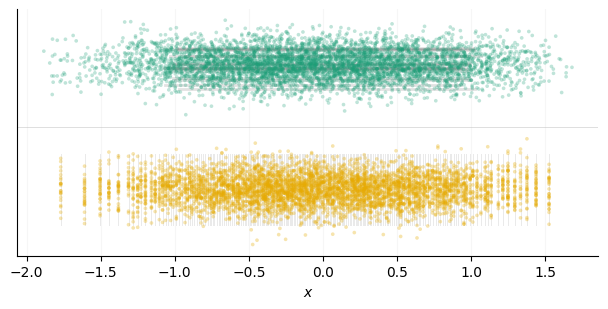

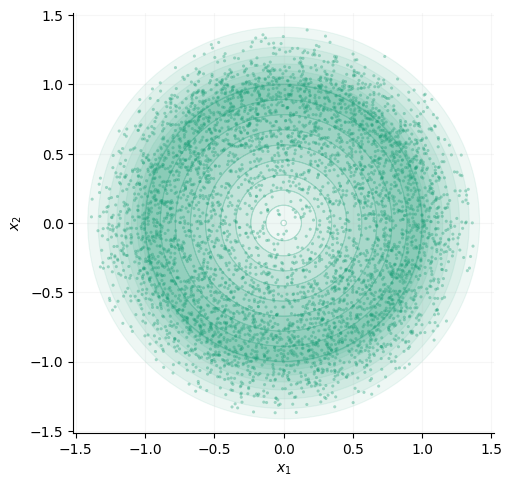

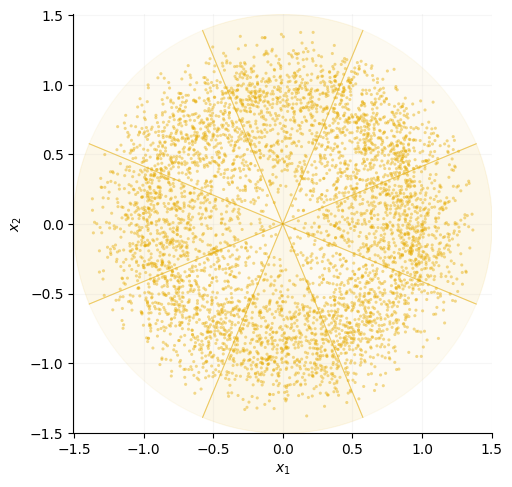

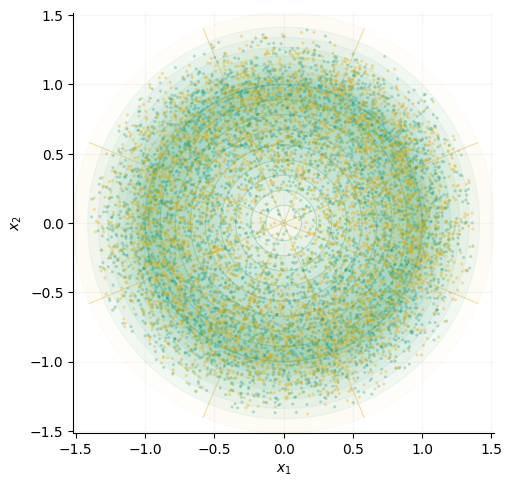

(<Figure size 520x520 with 1 Axes>, <Axes: xlabel='$x_1$', ylabel='$x_2$'>)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge


GREEN = "#1b9e77"
YELLOW = "#e6ab02"
GRAY = "#4d4d4d"


def _subsample_points(points, max_points=5000, seed=0):
    rng = np.random.default_rng(seed)
    points = np.asarray(points)

    if len(points) <= max_points:
        return points.copy()

    idx = rng.choice(len(points), size=max_points, replace=False)
    return points[idx]


def plot_experiment1_one_figure(
    P_bags_1,
    Q_bags_1,
    centers_1=None,
    q_support_1=None,
    max_points_each=5000,
    n_interval_hints=18,
    seed=0,
    save_path="experiment1_distribution_family.png"
):
    rng = np.random.default_rng(seed)

    P_points = np.asarray(P_bags_1).reshape(-1)
    Q_points = np.asarray(Q_bags_1).reshape(-1)

    P_plot = _subsample_points(P_points, max_points=max_points_each, seed=seed)
    Q_plot = _subsample_points(Q_points, max_points=max_points_each, seed=seed + 1)

    y_p = rng.normal(loc=0.08, scale=0.018, size=len(P_plot))
    y_q = rng.normal(loc=-0.08, scale=0.018, size=len(Q_plot))

    fig, ax = plt.subplots(figsize=(6.2, 3.2))

    if centers_1 is not None:
        centers_1 = np.asarray(centers_1)

        order = np.argsort(np.abs(centers_1))
        idx = order[:min(n_interval_hints, len(order))]
        y_levels = rng.normal(loc=0.08, scale=0.012, size=len(idx))

        for y, i in zip(y_levels, idx):
            c = centers_1[i]
            ax.plot(
                [c - 1.0, c + 1.0],
                [y, y],
                color=GRAY,
                linewidth=2.0,
                alpha=0.16,
                zorder=1
            )

    if q_support_1 is not None:
        q_support_1 = np.asarray(q_support_1)

        for x in q_support_1:
            ax.plot(
                [x, x],
                [-0.125, -0.035],
                color=GRAY,
                linewidth=0.7,
                alpha=0.12,
                zorder=1
            )

    ax.scatter(
        P_plot,
        y_p,
        s=7,
        c=GREEN,
        alpha=0.28,
        edgecolors="none",
        zorder=3
    )

    ax.scatter(
        Q_plot,
        y_q,
        s=7,
        c=YELLOW,
        alpha=0.32,
        edgecolors="none",
        zorder=3
    )

    ax.axhline(0.0, color="black", linewidth=0.6, alpha=0.15, zorder=0)

    ax.set_xlabel(r"$x$")
    ax.set_yticks([])
    ax.grid(alpha=0.10)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    return fig, ax


def _draw_annulus_regions(
    ax,
    P_ring_info_2,
    color=GREEN,
    n_ring_hints=10,
    alpha=0.070,
    edge_alpha=0.22,
    zorder=0
):
    P_ring_info_2 = np.asarray(P_ring_info_2)
    idx = np.linspace(0, len(P_ring_info_2) - 1, n_ring_hints).astype(int)

    for i in idx:
        r_in, r_out = P_ring_info_2[i]

        ring = Wedge(
            center=(0.0, 0.0),
            r=float(r_out),
            theta1=0.0,
            theta2=360.0,
            width=float(r_out - r_in),
            facecolor=color,
            edgecolor=color,
            linewidth=0.8,
            alpha=alpha,
            zorder=zorder
        )
        ax.add_patch(ring)

        inner_edge = Wedge(
            center=(0.0, 0.0),
            r=float(r_in),
            theta1=0.0,
            theta2=360.0,
            width=0.002,
            facecolor="none",
            edgecolor=color,
            linewidth=0.6,
            alpha=edge_alpha,
            zorder=zorder + 0.1
        )
        ax.add_patch(inner_edge)


def _draw_wedge_regions(
    ax,
    max_radius,
    n_rays=8,
    delta_theta=2.0 * np.pi / 8.0,
    color=YELLOW,
    alpha=0.080,
    edge_alpha=0.28,
    zorder=0
):
    base_angles = np.linspace(0.0, 2.0 * np.pi, n_rays, endpoint=False)

    for k, theta in enumerate(base_angles):
        theta_center_deg = np.degrees(theta)
        half_width_deg = np.degrees(delta_theta / 2.0)

        wedge = Wedge(
            center=(0.0, 0.0),
            r=float(max_radius),
            theta1=float(theta_center_deg - half_width_deg),
            theta2=float(theta_center_deg + half_width_deg),
            width=None,
            facecolor=color,
            edgecolor=color,
            linewidth=0.8,
            alpha=alpha if k % 2 == 0 else alpha * 0.55,
            zorder=zorder
        )
        ax.add_patch(wedge)

        theta_left = theta - delta_theta / 2.0
        theta_right = theta + delta_theta / 2.0

        ax.plot(
            [0.0, max_radius * np.cos(theta_left)],
            [0.0, max_radius * np.sin(theta_left)],
            color=color,
            linewidth=0.7,
            alpha=edge_alpha,
            zorder=zorder + 0.1
        )

        ax.plot(
            [0.0, max_radius * np.cos(theta_right)],
            [0.0, max_radius * np.sin(theta_right)],
            color=color,
            linewidth=0.7,
            alpha=edge_alpha,
            zorder=zorder + 0.1
        )


def _format_2d_axis(ax, lim):
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.grid(alpha=0.10, zorder=0)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)


def plot_experiment2_p_only(
    P_bags_2,
    P_ring_info_2,
    max_points_each=5000,
    n_ring_hints=10,
    seed=0,
    save_path="experiment2_P_only.png"
):
    P_points = np.asarray(P_bags_2).reshape(-1, 2)
    P_plot = _subsample_points(P_points, max_points=max_points_each, seed=seed)

    lim = 1.08 * np.linalg.norm(P_plot, axis=1).max()

    fig, ax = plt.subplots(figsize=(5.2, 5.2))

    _draw_annulus_regions(
        ax=ax,
        P_ring_info_2=P_ring_info_2,
        color=GREEN,
        n_ring_hints=n_ring_hints,
        alpha=0.075,
        edge_alpha=0.24,
        zorder=0
    )

    ax.scatter(
        P_plot[:, 0],
        P_plot[:, 1],
        s=5,
        c=GREEN,
        alpha=0.36,
        edgecolors="none",
        zorder=5
    )

    _format_2d_axis(ax, lim)

    plt.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    return fig, ax


def plot_experiment2_q_only(
    Q_bags_2,
    n_rays=8,
    delta_theta=2.0 * np.pi / 8.0,
    max_points_each=5000,
    seed=0,
    save_path="experiment2_Q_only.png"
):
    Q_points = np.asarray(Q_bags_2).reshape(-1, 2)
    Q_plot = _subsample_points(Q_points, max_points=max_points_each, seed=seed)

    lim = 1.08 * np.linalg.norm(Q_plot, axis=1).max()

    fig, ax = plt.subplots(figsize=(5.2, 5.2))

    _draw_wedge_regions(
        ax=ax,
        max_radius=lim,
        n_rays=n_rays,
        delta_theta=delta_theta,
        color=YELLOW,
        alpha=0.090,
        edge_alpha=0.32,
        zorder=0
    )

    ax.scatter(
        Q_plot[:, 0],
        Q_plot[:, 1],
        s=5,
        c=YELLOW,
        alpha=0.44,
        edgecolors="none",
        zorder=5
    )

    _format_2d_axis(ax, lim)

    plt.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    return fig, ax


def plot_experiment2_pq_together(
    P_bags_2,
    Q_bags_2,
    P_ring_info_2,
    n_rays=8,
    delta_theta=2.0 * np.pi / 8.0,
    max_points_each=5000,
    n_ring_hints=10,
    seed=0,
    save_path="experiment2_PQ_together.png"
):
    P_points = np.asarray(P_bags_2).reshape(-1, 2)
    Q_points = np.asarray(Q_bags_2).reshape(-1, 2)

    P_plot = _subsample_points(P_points, max_points=max_points_each, seed=seed)
    Q_plot = _subsample_points(Q_points, max_points=max_points_each, seed=seed + 1)

    all_points = np.vstack([P_plot, Q_plot])
    lim = 1.08 * np.linalg.norm(all_points, axis=1).max()

    fig, ax = plt.subplots(figsize=(5.2, 5.2))

    _draw_annulus_regions(
        ax=ax,
        P_ring_info_2=P_ring_info_2,
        color=GREEN,
        n_ring_hints=n_ring_hints,
        alpha=0.055,
        edge_alpha=0.18,
        zorder=0
    )

    _draw_wedge_regions(
        ax=ax,
        max_radius=lim,
        n_rays=n_rays,
        delta_theta=delta_theta,
        color=YELLOW,
        alpha=0.045,
        edge_alpha=0.18,
        zorder=1
    )

    ax.scatter(
        P_plot[:, 0],
        P_plot[:, 1],
        s=5,
        c=GREEN,
        alpha=0.30,
        edgecolors="none",
        zorder=5
    )

    ax.scatter(
        Q_plot[:, 0],
        Q_plot[:, 1],
        s=5,
        c=YELLOW,
        alpha=0.34,
        edgecolors="none",
        zorder=6
    )

    _format_2d_axis(ax, lim)

    plt.tight_layout()
    fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    return fig, ax


plot_experiment1_one_figure(
    P_bags_1=P_bags_1,
    Q_bags_1=Q_bags_1,
    centers_1=centers_1,
    q_support_1=q_support_1,
    max_points_each=5000,
    n_interval_hints=18,
    seed=123,
    save_path="experiment1_distribution_family.png"
)

plot_experiment2_p_only(
    P_bags_2=P_bags_2,
    P_ring_info_2=P_ring_info_2,
    max_points_each=5000,
    n_ring_hints=10,
    seed=123,
    save_path="experiment2_P_only.png"
)

plot_experiment2_q_only(
    Q_bags_2=Q_bags_2,
    n_rays=8,
    delta_theta=2.0 * np.pi / 8.0,
    max_points_each=5000,
    seed=123,
    save_path="experiment2_Q_only.png"
)

plot_experiment2_pq_together(
    P_bags_2=P_bags_2,
    Q_bags_2=Q_bags_2,
    P_ring_info_2=P_ring_info_2,
    n_rays=8,
    delta_theta=2.0 * np.pi / 8.0,
    max_points_each=5000,
    n_ring_hints=10,
    seed=123,
    save_path="experiment2_PQ_together.png"
)

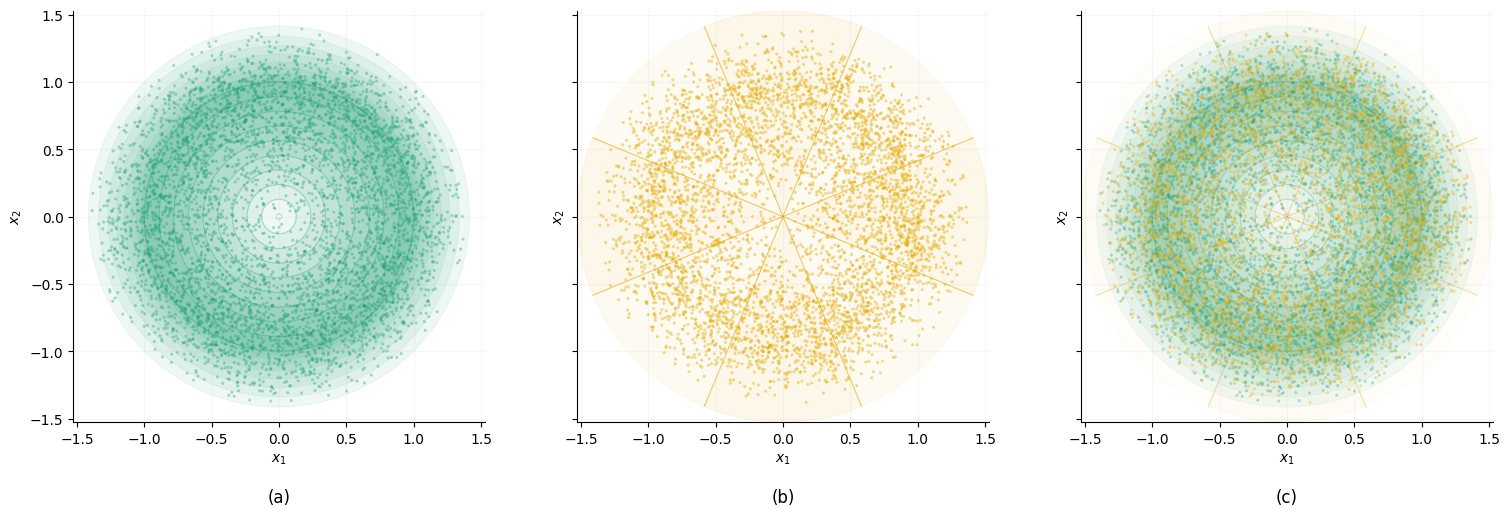

(<Figure size 1550x500 with 3 Axes>,
 array([<Axes: xlabel='$x_1$', ylabel='$x_2$'>,
        <Axes: xlabel='$x_1$', ylabel='$x_2$'>,
        <Axes: xlabel='$x_1$', ylabel='$x_2$'>], dtype=object))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge


GREEN = "#1b9e77"
YELLOW = "#e6ab02"


def _subsample_points(points, max_points=5000, seed=0):
    rng = np.random.default_rng(seed)
    points = np.asarray(points)

    if len(points) <= max_points:
        return points.copy()

    idx = rng.choice(len(points), size=max_points, replace=False)
    return points[idx]


def _draw_annulus_regions(
    ax,
    P_ring_info_2,
    color=GREEN,
    n_ring_hints=10,
    alpha=0.075,
    edge_alpha=0.24,
    zorder=0
):
    P_ring_info_2 = np.asarray(P_ring_info_2)
    idx = np.linspace(0, len(P_ring_info_2) - 1, n_ring_hints).astype(int)

    for i in idx:
        r_in, r_out = P_ring_info_2[i]

        ring = Wedge(
            center=(0.0, 0.0),
            r=float(r_out),
            theta1=0.0,
            theta2=360.0,
            width=float(r_out - r_in),
            facecolor=color,
            edgecolor=color,
            linewidth=0.7,
            alpha=alpha,
            zorder=zorder
        )
        ax.add_patch(ring)

        inner_edge = Wedge(
            center=(0.0, 0.0),
            r=float(r_in),
            theta1=0.0,
            theta2=360.0,
            width=0.002,
            facecolor="none",
            edgecolor=color,
            linewidth=0.6,
            alpha=edge_alpha,
            zorder=zorder + 0.1
        )
        ax.add_patch(inner_edge)


def _draw_wedge_regions(
    ax,
    max_radius,
    n_rays=8,
    delta_theta=2.0 * np.pi / 8.0,
    color=YELLOW,
    alpha=0.090,
    edge_alpha=0.32,
    zorder=0
):
    base_angles = np.linspace(0.0, 2.0 * np.pi, n_rays, endpoint=False)

    for k, theta in enumerate(base_angles):
        theta_center_deg = np.degrees(theta)
        half_width_deg = np.degrees(delta_theta / 2.0)

        wedge = Wedge(
            center=(0.0, 0.0),
            r=float(max_radius),
            theta1=float(theta_center_deg - half_width_deg),
            theta2=float(theta_center_deg + half_width_deg),
            width=None,
            facecolor=color,
            edgecolor=color,
            linewidth=0.7,
            alpha=alpha if k % 2 == 0 else alpha * 0.55,
            zorder=zorder
        )
        ax.add_patch(wedge)

        theta_left = theta - delta_theta / 2.0
        theta_right = theta + delta_theta / 2.0

        ax.plot(
            [0.0, max_radius * np.cos(theta_left)],
            [0.0, max_radius * np.sin(theta_left)],
            color=color,
            linewidth=0.7,
            alpha=edge_alpha,
            zorder=zorder + 0.1
        )

        ax.plot(
            [0.0, max_radius * np.cos(theta_right)],
            [0.0, max_radius * np.sin(theta_right)],
            color=color,
            linewidth=0.7,
            alpha=edge_alpha,
            zorder=zorder + 0.1
        )


def _format_2d_axis(ax, lim):
    ax.set_xlabel(r"$x_1$")
    ax.set_ylabel(r"$x_2$")
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.grid(alpha=0.10, zorder=0)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)


def plot_experiment2_three_panel_long(
    P_bags_2,
    Q_bags_2,
    P_ring_info_2,
    n_rays=8,
    delta_theta=2.0 * np.pi / 8.0,
    max_points_each=5000,
    n_ring_hints=10,
    seed=123,
    save_path="experiment2_three_panel_long.png",
    save_pdf=True,
    panel_labels=True
):
    P_points = np.asarray(P_bags_2).reshape(-1, 2)
    Q_points = np.asarray(Q_bags_2).reshape(-1, 2)

    P_plot = _subsample_points(P_points, max_points=max_points_each, seed=seed)
    Q_plot = _subsample_points(Q_points, max_points=max_points_each, seed=seed + 1)

    all_points = np.vstack([P_plot, Q_plot])
    max_point_radius = np.linalg.norm(all_points, axis=1).max()

    P_ring_info_2 = np.asarray(P_ring_info_2)
    max_ring_radius = P_ring_info_2[:, 1].max()

    max_radius = max(max_point_radius, max_ring_radius)
    lim = 1.08 * max_radius

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15.5, 5.0),
        sharex=True,
        sharey=True
    )

    ax = axes[0]

    _draw_annulus_regions(
        ax=ax,
        P_ring_info_2=P_ring_info_2,
        color=GREEN,
        n_ring_hints=n_ring_hints,
        alpha=0.075,
        edge_alpha=0.24,
        zorder=0
    )

    ax.scatter(
        P_plot[:, 0],
        P_plot[:, 1],
        s=5,
        c=GREEN,
        alpha=0.36,
        edgecolors="none",
        zorder=5
    )

    _format_2d_axis(ax, lim)

    ax = axes[1]

    _draw_wedge_regions(
        ax=ax,
        max_radius=lim,
        n_rays=n_rays,
        delta_theta=delta_theta,
        color=YELLOW,
        alpha=0.090,
        edge_alpha=0.32,
        zorder=0
    )

    ax.scatter(
        Q_plot[:, 0],
        Q_plot[:, 1],
        s=5,
        c=YELLOW,
        alpha=0.44,
        edgecolors="none",
        zorder=5
    )

    _format_2d_axis(ax, lim)

    ax = axes[2]

    _draw_annulus_regions(
        ax=ax,
        P_ring_info_2=P_ring_info_2,
        color=GREEN,
        n_ring_hints=n_ring_hints,
        alpha=0.055,
        edge_alpha=0.18,
        zorder=0
    )

    _draw_wedge_regions(
        ax=ax,
        max_radius=lim,
        n_rays=n_rays,
        delta_theta=delta_theta,
        color=YELLOW,
        alpha=0.045,
        edge_alpha=0.18,
        zorder=1
    )

    ax.scatter(
        P_plot[:, 0],
        P_plot[:, 1],
        s=5,
        c=GREEN,
        alpha=0.30,
        edgecolors="none",
        zorder=5
    )

    ax.scatter(
        Q_plot[:, 0],
        Q_plot[:, 1],
        s=5,
        c=YELLOW,
        alpha=0.34,
        edgecolors="none",
        zorder=6
    )

    _format_2d_axis(ax, lim)

    if panel_labels:
        labels = [r"(a)", r"(b)", r"(c)"]
        for ax, lab in zip(axes, labels):
            ax.text(
                0.5,
                -0.16,
                lab,
                transform=ax.transAxes,
                ha="center",
                va="top",
                fontsize=12
            )

    plt.tight_layout(w_pad=2.2)

    fig.savefig(save_path, dpi=300, bbox_inches="tight")

    if save_pdf:
        pdf_path = save_path.replace(".png", ".pdf")
        fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()

    return fig, axes


plot_experiment2_three_panel_long(
    P_bags_2=P_bags_2,
    Q_bags_2=Q_bags_2,
    P_ring_info_2=P_ring_info_2,
    n_rays=8,
    delta_theta=2.0 * np.pi / 8.0,
    max_points_each=5000,
    n_ring_hints=10,
    seed=123,
    save_path="experiment2_three_panel_long.png",
    save_pdf=True,
    panel_labels=True
)


---
_End of Experiment 1._


# ============================================================
# Experiment 2 — Two-sample test, Case 2 (Annulus family vs. Beta-radial parametric)
# ============================================================

**Paper §4.1, Case 2**

Regular batches: $P = \{\mathrm{Unif}[\text{2D annulus with fixed area}],\; r_0 \sim \mathrm{Unif}[0.02, 1]\}$.

Abnormal batches: $Q = \{(\omega, r),\; \omega \sim \mathrm{Unif}(0, 2\pi],\; r \sim \sqrt{2}\,\mathrm{Beta}(4, 3)\}$.

Again, the abnormal data clouds resemble the pooled regular batches, so classical tests (energy, MMD) fail while the WSD-based p-value detects them.

_Source notebook:_ `Two_sample_test_2_beta.ipynb`

---


# Experiment 2: annulus $P$ vs Beta-radial parametric $Q$

Self-contained variant of Experiment 2 from `Two_sample_test.ipynb`.

* $P$: 100 annulus distributions with fixed area and increasing inner radius (unchanged).
* $Q$: continuous parametric distribution
$$ R = \sqrt 2 \cdot U,\quad U\sim\mathrm{Beta}(\alpha,\beta), \qquad
\theta\sim\mathrm{Unif}[0,2\pi),\qquad X = (R\cos\theta, R\sin\theta). $$
Default $(\alpha,\beta)=(4,3)$. The Beta radial mass density is single-peaked,
left-rising / right-falling on $[0,\sqrt 2]$, mimicking $P$'s pooled radial mass.

Then run point-level tests (Energy, MMD), the WSD $R$-test, and a Monte Carlo
sweep under both the alternative ($Q\ne P$) and the null ($P'\sim P$ as $Q$).


In [ ]:
import gc
import warnings

import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from scipy.spatial.distance import pdist, squareform

from joblib import Parallel, delayed
import ot

SEED = 42

# --- annulus family (P) ---
N_P = 100
N_Q = 100
M_PER_DISTRIBUTION = 50
R_IN_MIN = 0.02
R_IN_MAX = 1.0
AREA_CONST = np.pi * (1.0 ** 2 - R_IN_MIN ** 2)

# --- parametric Beta-radial Q (continuous) ---
Q_BETA_ALPHA = 4.0
Q_BETA_BETA  = 3.0
R_MAX = float(np.sqrt(R_IN_MAX ** 2 + AREA_CONST / np.pi))  # ~1.414, Beta scale

# --- testing config ---
B_POINT = 500
R_BINS = 10

# --- Sinkhorn ---
EPS = 1e-12
SINKHORN_REG = 0.05
SINKHORN_MAX_ITER = 5000
SINKHORN_STOP_THR = 1e-9

print(f'R_MAX = {R_MAX:.4f}')
print(f'Q radial: R = R_MAX * Beta(alpha={Q_BETA_ALPHA}, beta={Q_BETA_BETA}); '
      f'angle uniform on [0, 2pi)')
_mode = R_MAX * (Q_BETA_ALPHA-1)/(Q_BETA_ALPHA+Q_BETA_BETA-2)
_mean = R_MAX * Q_BETA_ALPHA/(Q_BETA_ALPHA+Q_BETA_BETA)
print(f'  Beta mode (radial) = {_mode:.3f},  mean (radial) = {_mean:.3f}')


## Annulus family $P$

$$
P_i = \mathrm{Unif}\big(\{x\in\mathbb R^2 : r_{\text{in},i} \le \|x\|\le r_{\text{out},i}\}\big),
\qquad
\pi(r_{\text{out},i}^2 - r_{\text{in},i}^2)\equiv \mathrm{const},
$$

with $r_{\text{in},i}$ linearly increasing on $[0.02, 1.00]$.

In [ ]:
def sample_annulus(n, r_in, r_out, rng):
    theta = rng.uniform(0.0, 2.0 * np.pi, size=n)
    u = rng.uniform(0.0, 1.0, size=n)
    r = np.sqrt(r_in ** 2 + u * (r_out ** 2 - r_in ** 2))
    return np.column_stack([r * np.cos(theta), r * np.sin(theta)])


def annulus_outer_from_area(r_in, area):
    return np.sqrt(r_in ** 2 + area / np.pi)


def sample_annulus_family(n_bags=N_P, m=M_PER_DISTRIBUTION,
                          r_in_min=R_IN_MIN, r_in_max=R_IN_MAX,
                          area_const=AREA_CONST, rng=None):
    if rng is None:
        rng = np.random.default_rng(0)
    r_in_grid = np.linspace(r_in_min, r_in_max, n_bags)
    bags = []
    info = []
    for r_in in r_in_grid:
        r_out = annulus_outer_from_area(r_in, area_const)
        bags.append(sample_annulus(m, r_in, r_out, rng))
        info.append((r_in, r_out))
    return np.asarray(bags, dtype=np.float64), np.asarray(info, dtype=np.float64)


rng = np.random.default_rng(SEED)
P_bags, P_ring_info = sample_annulus_family(rng=rng)
P_point = P_bags.reshape(-1, 2)
print(f'P_bags shape: {P_bags.shape}')
print(f'P pooled point shape: {P_point.shape}')
print(f'inner radii range: {P_ring_info[:,0].min():.3f} to {P_ring_info[:,0].max():.3f}')
print(f'outer radii range: {P_ring_info[:,1].min():.3f} to {P_ring_info[:,1].max():.3f}')


## Parametric $Q$ (continuous): Beta radial $\times$ uniform angle

$$
R = \sqrt 2 \cdot U,\qquad U\sim\mathrm{Beta}(\alpha,\beta),\qquad
\theta\sim\mathrm{Unif}[0,2\pi),\qquad X = (R\cos\theta, R\sin\theta).
$$

With $(\alpha,\beta)=(4,3)$: Beta mode at $u^*=3/5=0.6$, so radial mode
$r^*=0.6\sqrt 2 \approx 0.85$. Mass concentrates in an off-center ring,
vanishing at $r=0$ and $r=\sqrt 2$, mimicking $P$'s peak (true $P$ peak is
at $r\approx 1$; Beta(4,3) is a coarse fit – tweak $\alpha,\beta$ to taste
or use MLE $(\alpha,\beta)\approx(4.08, 2.46)$ for a tighter match).

No discretization: radii sampled with `rng.beta`, angles with `rng.uniform`.


In [ ]:
def generate_q_bags_2d(rng, n_bags=N_Q, m=M_PER_DISTRIBUTION,
                       alpha=Q_BETA_ALPHA, beta=Q_BETA_BETA, r_max=R_MAX):
    """Each bag: m i.i.d. samples from the continuous distribution
        R = r_max * Beta(alpha, beta),   theta ~ Unif[0, 2*pi),
        X = (R cos theta, R sin theta).
    Returns shape (n_bags, m, 2)."""
    R = r_max * rng.beta(alpha, beta, size=(n_bags, m))
    theta = rng.uniform(0.0, 2.0 * np.pi, size=(n_bags, m))
    return np.stack([R * np.cos(theta), R * np.sin(theta)], axis=-1)


Q_bags = generate_q_bags_2d(rng)
Q_point = Q_bags[0].copy()

_radii = np.linalg.norm(Q_point, axis=1)
print(f'Q_bags shape: {Q_bags.shape}')
print(f'Q point sample shape: {Q_point.shape}')
print(f'empirical Q radii: mean={_radii.mean():.3f}, std={_radii.std():.3f}, '
      f'min={_radii.min():.3f}, max={_radii.max():.3f}')


## Visualization

Side-by-side scatter of pooled $P$ vs one $Q$ bag.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].scatter(P_point[:, 0], P_point[:, 1], s=4, alpha=0.35)
axes[0].set_title(f'P pooled point sample ({P_point.shape[0]} pts, annulus family)')
axes[0].set_aspect('equal')
axes[0].set_xlim(-R_MAX*1.05, R_MAX*1.05); axes[0].set_ylim(-R_MAX*1.05, R_MAX*1.05)

axes[1].scatter(Q_point[:, 0], Q_point[:, 1], s=18, alpha=0.7)
axes[1].set_title(f'Q single point-level sample (50 pts, $R\\sim\\sqrt{{2}}\\cdot\\mathrm{{Beta}}({Q_BETA_ALPHA:g},{Q_BETA_BETA:g})$)')
axes[1].set_aspect('equal')
axes[1].set_xlim(-R_MAX*1.05, R_MAX*1.05); axes[1].set_ylim(-R_MAX*1.05, R_MAX*1.05)
plt.tight_layout(); plt.show()


## Point level two sample tests

Energy distance and MMD with permutation $p$-values.
KS is intrinsically 1D and not used here.

In [ ]:
def energy_statistic_from_distance(D, idx_x, idx_y):
    idx_x = np.asarray(idx_x); idx_y = np.asarray(idx_y)
    Dxx = D[np.ix_(idx_x, idx_x)]
    Dyy = D[np.ix_(idx_y, idx_y)]
    Dxy = D[np.ix_(idx_x, idx_y)]
    return float(2.0 * Dxy.mean() - Dxx.mean() - Dyy.mean())


def energy_permutation_test_2d(X, Y, B=B_POINT, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    X = np.asarray(X, dtype=np.float64); Y = np.asarray(Y, dtype=np.float64)
    Z = np.vstack([X, Y]); m = X.shape[0]; N = Z.shape[0]
    D = squareform(pdist(Z, metric='euclidean'))
    idx_x = np.arange(m); idx_y = np.arange(m, N)
    obs = energy_statistic_from_distance(D, idx_x, idx_y)
    perm_stats = np.empty(B, dtype=float)
    for b in range(B):
        perm = rng.permutation(N)
        perm_stats[b] = energy_statistic_from_distance(D, perm[:m], perm[m:])
    p_value = (1.0 + np.sum(perm_stats >= obs)) / (B + 1.0)
    del D; gc.collect()
    return {'test': 'Energy', 'statistic': float(obs), 'p_value': float(p_value)}


def median_heuristic_sigma_2d(Z):
    Z = np.asarray(Z, dtype=np.float64)
    distances = pdist(Z, metric='euclidean')
    positive = distances[distances > 0]
    if positive.size == 0:
        return 1.0
    return float(np.median(positive))


def mmd2_unbiased_from_kernel(K, idx_x, idx_y):
    idx_x = np.asarray(idx_x); idx_y = np.asarray(idx_y)
    m = len(idx_x); n = len(idx_y)
    Kxx = K[np.ix_(idx_x, idx_x)]
    Kyy = K[np.ix_(idx_y, idx_y)]
    Kxy = K[np.ix_(idx_x, idx_y)]
    term_x = (Kxx.sum() - np.trace(Kxx)) / (m * (m - 1))
    term_y = (Kyy.sum() - np.trace(Kyy)) / (n * (n - 1))
    term_xy = 2.0 * Kxy.mean()
    return float(term_x + term_y - term_xy)


def mmd_permutation_test_2d(X, Y, B=B_POINT, rng=None, sigma=None):
    if rng is None:
        rng = np.random.default_rng()
    X = np.asarray(X, dtype=np.float64); Y = np.asarray(Y, dtype=np.float64)
    Z = np.vstack([X, Y]); m = X.shape[0]; N = Z.shape[0]
    if sigma is None:
        sigma = median_heuristic_sigma_2d(Z)
    sqD = squareform(pdist(Z, metric='sqeuclidean'))
    K = np.exp(-sqD / (2.0 * sigma ** 2))
    idx_x = np.arange(m); idx_y = np.arange(m, N)
    obs = mmd2_unbiased_from_kernel(K, idx_x, idx_y)
    perm_stats = np.empty(B, dtype=float)
    for b in range(B):
        perm = rng.permutation(N)
        perm_stats[b] = mmd2_unbiased_from_kernel(K, perm[:m], perm[m:])
    p_value = (1.0 + np.sum(perm_stats >= obs)) / (B + 1.0)
    del sqD, K; gc.collect()
    return {'test': 'MMD', 'statistic': float(obs), 'p_value': float(p_value),
            'sigma': float(sigma)}


energy_result = energy_permutation_test_2d(P_point, Q_point, B=B_POINT, rng=rng)
mmd_result    = mmd_permutation_test_2d   (P_point, Q_point, B=B_POINT, rng=rng)
print('Single-rep point-level tests:')
print(' ', energy_result)
print(' ', mmd_result)


## WSD $R$-test (single replication)

Each bag is treated as an empirical distribution. For each $Q$ bag we compute
its rank statistic $R$ relative to the WSD depths of the $P$ population, then
chi-square against $\mathrm{Unif}(0,1)$ with 10 bins.

In [ ]:
def _sinkhorn_plan(wi, wj, C):
    wi = np.asarray(wi, dtype=np.float64); wj = np.asarray(wj, dtype=np.float64)
    C = np.asarray(C, dtype=np.float64)
    wi = wi / max(wi.sum(), EPS); wj = wj / max(wj.sum(), EPS)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        Pi = ot.sinkhorn(wi, wj, C, reg=SINKHORN_REG, method='sinkhorn_log',
                         numItermax=SINKHORN_MAX_ITER, stopThr=SINKHORN_STOP_THR,
                         warn=False)
    return np.ascontiguousarray(Pi, dtype=np.float64)


def compute_WSD_X(X, labels, n_jobs=-1):
    M, n, d, _ = X.shape
    coords  = X[..., 0].astype(np.float64, copy=False)
    weights = X[:, :, 0, 1].astype(np.float64, copy=False)
    s = weights.sum(axis=1, keepdims=True); s[s <= 0] = 1.0
    weights = weights / s

    def _wsd_i(i):
        wi = np.ascontiguousarray(weights[i]); Xi = np.ascontiguousarray(coords[i])
        members = np.where(labels == labels[i])[0]
        members = members[members != i]
        if members.size == 0:
            return 1.0
        m_acc = np.zeros((n, d), dtype=np.float64)
        for j in members:
            wj = np.ascontiguousarray(weights[j]); Xj = np.ascontiguousarray(coords[j])
            C = np.ascontiguousarray(ot.dist(Xi, Xj, metric='euclidean')**2)
            Pi = _sinkhorn_plan(wi, wj, C)
            T_vals = (Pi @ Xj) / (wi[:, None] + EPS)
            W2 = np.sqrt((Pi * C).sum()) + EPS
            m_acc += (Xi - T_vals) / W2
        m_vec = m_acc / members.size
        return 1.0 - np.sqrt(np.sum(wi * np.sum(m_vec**2, axis=1)))

    return np.array(Parallel(n_jobs=n_jobs)(delayed(_wsd_i)(i) for i in range(M)))


def compute_WSD_Y(Y, X, n_jobs=-1):
    My, n, d, _ = Y.shape; Mx = X.shape[0]
    coordsY  = Y[..., 0].astype(np.float64, copy=False)
    coordsX  = X[..., 0].astype(np.float64, copy=False)
    weightsY = Y[:, :, 0, 1].astype(np.float64, copy=False)
    weightsX = X[:, :, 0, 1].astype(np.float64, copy=False)
    sY = weightsY.sum(axis=1, keepdims=True); sY[sY <= 0] = 1.0
    sX = weightsX.sum(axis=1, keepdims=True); sX[sX <= 0] = 1.0
    weightsY = weightsY / sY; weightsX = weightsX / sX

    def _wsd_y(m):
        wy = np.ascontiguousarray(weightsY[m]); Yp = np.ascontiguousarray(coordsY[m])
        if Mx == 0:
            return 1.0
        m_acc = np.zeros((n, d), dtype=np.float64)
        for k in range(Mx):
            wk = np.ascontiguousarray(weightsX[k]); Xp = np.ascontiguousarray(coordsX[k])
            C = np.ascontiguousarray(ot.dist(Yp, Xp, metric='euclidean')**2)
            Pi = _sinkhorn_plan(wy, wk, C)
            T_vals = (Pi @ Xp) / (wy[:, None] + EPS)
            W2 = np.sqrt((Pi * C).sum()) + EPS
            m_acc += (Yp - T_vals) / W2
        m_vec = m_acc / Mx
        return 1.0 - np.sqrt(np.sum(wy * np.sum(m_vec**2, axis=1)))

    return np.array(Parallel(n_jobs=n_jobs)(delayed(_wsd_y)(m) for m in range(My)))


def bags_to_wsd_array_2d(bags):
    bags = np.asarray(bags, dtype=np.float64)
    M, m, d = bags.shape
    X = np.zeros((M, m, d, 2), dtype=np.float64)
    X[..., 0] = bags
    X[:, :, 0, 1] = 1.0 / m
    return X


In [ ]:
# Single WSD R-test on the original P/Q populations
X_wsd = bags_to_wsd_array_2d(P_bags)
Y_wsd = bags_to_wsd_array_2d(Q_bags)
labels_P = np.zeros(X_wsd.shape[0], dtype=int)

depths_P = compute_WSD_X(X_wsd, labels_P, n_jobs=-1)
depths_Q = compute_WSD_Y(Y_wsd, X_wsd, n_jobs=-1)

R_values = np.mean(depths_P[:, None] <= depths_Q[None, :], axis=0)

obs_counts, bin_edges = np.histogram(R_values, bins=R_BINS, range=(0.0, 1.0))
exp_counts = np.repeat(len(R_values) / R_BINS, R_BINS)
chi2_result = stats.chisquare(f_obs=obs_counts, f_exp=exp_counts)

print('depths_P summary:', dict(min=float(depths_P.min()),
                                mean=float(depths_P.mean()),
                                max=float(depths_P.max())))
print('depths_Q summary:', dict(min=float(depths_Q.min()),
                                mean=float(depths_Q.mean()),
                                max=float(depths_Q.max())))
print('R values summary:', dict(min=float(R_values.min()),
                                mean=float(R_values.mean()),
                                max=float(R_values.max())))
print('observed bin counts:', obs_counts)
print('chi^2 vs Uniform(0,1):',
      dict(stat=float(chi2_result.statistic), p_value=float(chi2_result.pvalue)))

plt.figure(figsize=(7, 4))
plt.hist(R_values, bins=R_BINS, range=(0.0, 1.0), edgecolor='black')
plt.axhline(len(R_values)/R_BINS, linestyle=':', label='Uniform expected count')
plt.xlabel('R statistic'); plt.ylabel('count')
plt.title('Histogram of WSD-based R statistics')
plt.legend(); plt.tight_layout(); plt.show()


## Monte Carlo replication study (50 reps)

* **Alternative**: keep $P$ and `depths_P` fixed; resample $Q$ from the
  parametric Beta-radial distribution per rep.
* **Null**: resample a fresh $P'\sim P$ annulus family per rep and treat it as
  $Q$. Should fail to reject; reports empirical Type I error.

In [ ]:
N_REPS = 20  # seeds will be 0..N_REPS-1
ALPHA = 0.05


def summarize_pvals(pvals):
    p = np.asarray(pvals, dtype=float)
    if p.size == 0:
        return {'n': 0, 'median': float('nan'), 'mean': float('nan'),
                'std': float('nan'), 'power': float('nan')}
    return {
        'n': int(p.size),
        'median': float(np.median(p)),
        'mean': float(np.mean(p)),
        'std': float(np.std(p, ddof=1)) if p.size > 1 else 0.0,
        'power': float(np.mean(p < ALPHA)),
    }


def wsd_rtest_pvalue(Q_bags_array, X_wsd_ref, depths_P_ref,
                     n_bins=R_BINS, n_jobs=-1):
    Y_wsd_local = bags_to_wsd_array_2d(Q_bags_array)
    depths_Q_local = compute_WSD_Y(Y_wsd_local, X_wsd_ref, n_jobs=n_jobs)
    R_local = np.mean(depths_P_ref[:, None] <= depths_Q_local[None, :], axis=0)
    obs, _ = np.histogram(R_local, bins=n_bins, range=(0.0, 1.0))
    exp = np.repeat(len(R_local) / n_bins, n_bins)
    return float(stats.chisquare(f_obs=obs, f_exp=exp).pvalue)


print(f'Will run N_REPS={N_REPS} replications per regime.')


In [ ]:
# Alternative regime: resample Q from the parametric Beta-radial distribution
import time as _time
pvals_alt = {'Energy': [], 'MMD': [], 'WSD R-test': []}
_t0 = _time.time()
for r in range(N_REPS):
    rng_r = np.random.default_rng(r)
    Q_bags_rep = generate_q_bags_2d(rng_r)
    Q_point_rep = Q_bags_rep[0].copy()
    pvals_alt['Energy'].append(
        energy_permutation_test_2d(P_point, Q_point_rep, B=B_POINT, rng=rng_r)['p_value'])
    pvals_alt['MMD'].append(
        mmd_permutation_test_2d(P_point, Q_point_rep, B=B_POINT, rng=rng_r)['p_value'])
    p_R = wsd_rtest_pvalue(Q_bags_rep, X_wsd, depths_P)
    pvals_alt['WSD R-test'].append(p_R)
    print(f'  alt rep {r+1:2d}/{N_REPS}  '
          f'Energy={pvals_alt["Energy"][-1]:.3e}  '
          f'MMD={pvals_alt["MMD"][-1]:.3e}  '
          f'WSD={p_R:.3e}  ({_time.time()-_t0:.0f}s)')

print('\n[alt] summary:')
for name, pv in pvals_alt.items():
    print(f'  {name:11s}', summarize_pvals(pv))


In [ ]:
# Null regime: resample P' ~ P (same annulus family) and treat as Q
import time as _time
pvals_null = {'Energy': [], 'MMD': [], 'WSD R-test': []}
_t0 = _time.time()
for r in range(N_REPS):
    rng_r = np.random.default_rng(r)
    Pprime_bags, _ = sample_annulus_family(rng=rng_r)
    Q_point_rep = Pprime_bags[0].copy()
    pvals_null['Energy'].append(
        energy_permutation_test_2d(P_point, Q_point_rep, B=B_POINT, rng=rng_r)['p_value'])
    pvals_null['MMD'].append(
        mmd_permutation_test_2d(P_point, Q_point_rep, B=B_POINT, rng=rng_r)['p_value'])
    p_R = wsd_rtest_pvalue(Pprime_bags, X_wsd, depths_P)
    pvals_null['WSD R-test'].append(p_R)
    print(f'  null rep {r+1:2d}/{N_REPS}  '
          f'Energy={pvals_null["Energy"][-1]:.3e}  '
          f'MMD={pvals_null["MMD"][-1]:.3e}  '
          f'WSD={p_R:.3e}  ({_time.time()-_t0:.0f}s)')

print('\n[null] summary:')
for name, pv in pvals_null.items():
    print(f'  {name:11s}', summarize_pvals(pv))


In [ ]:
# Aggregate + print LaTeX block
all_results = {'alt': pvals_alt, 'null': pvals_null}
method_order = ['Energy', 'MMD', 'WSD R-test']

print('=' * 78)
print(f'Summary across N_REPS={N_REPS} reps at alpha={ALPHA}')
print('=' * 78)
header = (f'{"regime":6s}  {"method":11s}  {"n":>3s}  {"median p":>11s}  '
          f'{"mean p":>11s}  {"std p":>11s}  {"power/TypeI":>11s}')
print(header); print('-' * len(header))
for tag, dct in all_results.items():
    for m in method_order:
        s = summarize_pvals(dct[m])
        print(f'{tag:6s}  {m:11s}  {s["n"]:3d}  {s["median"]:11.3e}  '
              f'{s["mean"]:11.3e}  {s["std"]:11.3e}  {s["power"]:11.3f}')

# save
_payload = {}
for tag, dct in all_results.items():
    for m, pv in dct.items():
        key = f'{tag}__{m.replace(" ", "_").replace("-", "_")}'
        _payload[key] = np.asarray(pv, dtype=float)
_payload['meta'] = np.array([N_REPS, ALPHA, Q_BETA_ALPHA, Q_BETA_BETA])
np.savez('mc_results_exp2_beta.npz', **_payload)
print(f'\nSaved {len(_payload)} arrays to mc_results_exp2_beta.npz')

# LaTeX
def _fmt(method, dct, regime):
    if method not in dct or len(dct[method]) == 0:
        return r'n/a'
    s = summarize_pvals(dct[method])
    if regime == 'alt':
        return f'{s["power"]:.2f} ({s["median"]:.2e})'
    return f'{s["power"]:.2f} ({s["median"]:.2f})'

tex = []
tex.append(r'% Auto-generated by Two_sample_test_2_beta.ipynb')
tex.append(rf'% N_REPS={N_REPS}, alpha={ALPHA}, '
           rf'Beta({Q_BETA_ALPHA},{Q_BETA_BETA}) on [0,sqrt(2)] (continuous)')
tex.append(r'\begin{table}[H]\centering')
tex.append(rf'\caption{{Experiment~2 (Beta-radial $Q$). Empirical power '
           rf'and Type~I error over $N_{{\mathrm{{rep}}}}={N_REPS}$ replications '
           rf'at $\alpha={ALPHA}$. Median $p$-value in parentheses. '
           rf'$R=\sqrt 2\cdot\mathrm{{Beta}}({Q_BETA_ALPHA},{Q_BETA_BETA})$, '
           rf'$\theta\sim\mathrm{{Unif}}[0,2\pi)$, sampled continuously.}}')
tex.append(r'\label{tab:exp2_beta}')
tex.append(r'\begin{tabular}{lccc}\toprule')
tex.append(r' & Energy & MMD & WSD $R$-test \\\midrule')
tex.append('Alternative ($Q$ vs.\\ $P$-ref) '
           f'& {_fmt("Energy", pvals_alt, "alt")} '
           f'& {_fmt("MMD", pvals_alt, "alt")} '
           f'& {_fmt("WSD R-test", pvals_alt, "alt")} \\\\')
tex.append("Null ($P'\\sim P$) "
           f'& {_fmt("Energy", pvals_null, "null")} '
           f'& {_fmt("MMD", pvals_null, "null")} '
           f'& {_fmt("WSD R-test", pvals_null, "null")} \\\\')
tex.append(r'\bottomrule\end{tabular}\end{table}')
tex_block = '\n'.join(tex)

print('\n' + '=' * 78)
print('LaTeX block (also saved to mc_table_exp2_beta.tex):')
print('=' * 78)
print(tex_block)
with open('mc_table_exp2_beta.tex', 'w') as _f:
    _f.write(tex_block)



---
_End of Experiment 2._


# ============================================================
# Experiment 3 — Online regression with $\theta$-jitter anomalies
# ============================================================

**Paper §4.2**

Linear regression streaming setting with $d=5$, $n=60$, $T=120$. Coefficient $\theta^t$ drifts as a random walk; anomalous batches inject per-sample latent coefficient jitter $u_i^t \sim \mathcal{N}(0, 0.6^2 I_{d \times d})$. We compare the WSD-based p-value against four classical detectors: gradient norm, Mean-grad $L_2$, Hotelling $T^2$, and MMD (RBF), via ROC / AUC over 20 seeds, and report a threshold table.

_Source notebook:_ `online_regression_theta_jitter.ipynb`

---


# Online Regression with WSD-based p-value Anomaly Detection — Intra-batch Theta-Jitter Anomaly

Regression counterpart of the classification WSD-based p-value pipeline.
Each streaming batch is encoded as the empirical measure of its
**per-sample residual gradients**
$$g_i \;=\; (x_i^\top \hat\theta_t - y_i)\, x_i \;\in\; \mathbb{R}^d.$$

**Setting.** Paper Eq. (14) generative process,
$\varepsilon_i^t \sim \mathcal{N}(0, 1)$,
$\theta^{t+1} = \theta^t + \mathcal{N}(0, 0.1^2)$,
$\theta^0$ coordinates iid from $\mathrm{Unif}\big[(-2,-1)\cup(0.5,2.5)\big]$.
$T=120$, $W=20$, $B=60$, $d=5$, anomaly rate $\rho = 0.15$, burn-in = 25.

**Modified anomaly: intra-batch $\theta$-jitter.** Instead of paper's
batch-level coefficient shift, each sample in an anomaly batch has its
own zero-mean jitter on $\theta$:
$$y_i^t \;=\; \langle x_i^t,\ \theta^t + u_i^t\rangle + \varepsilon_i^t,
\quad u_i^t \sim \mathcal{N}(0,\ \sigma_u^2 I).$$

**Why this makes baselines fail.** With $u_i$ zero-mean i.i.d.,
$\mathbb{E}[\bar g_t \mid \mathrm{anom}] = 0$ — the *batch mean gradient*
is unbiased in anomaly batches just as in clean batches. So:
- **Hotelling $T^2$** and **Mean-grad $L_2$** look at $\bar g_t - \hat\mu$,
  which is approximately zero in both cases → they cannot distinguish.
- **WSD-based p-value** and **MMD** look at the *full distribution* of
  gradients; the jitter inflates the per-sample gradient variance, which
  changes the shape of the empirical measure → they can detect.

This matches the paper Table 3 pattern (baselines $T^2$, MG, MMD all weak;
WSD dominant).

**Identical sliding window for every detector.** WSD-based p-value and
all four baselines share the same sliding reference window
$\{\eta_{t-W},\dots,\eta_{t-1}\}$ — no fixed-reference trick.

**Multi-seed.** Step 10b reruns the pipeline for 20 independent seeds.


## Step 1 — Setup

In [ ]:
import numpy as np
import ot
import matplotlib.pyplot as plt
from collections import deque
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import kstest, chisquare
import time
import warnings
warnings.filterwarnings("ignore", message="Sinkhorn did not converge")
np.set_printoptions(precision=3, suppress=True)

CHI2_BINS = 10   # bins for chi-square uniformity test on clean WSD p-values


## Step 2 — Configuration

| Parameter | Symbol | Value | Meaning |
|---|---|---|---|
| Stream length | $T$ | 120 | total streaming rounds |
| Window size (WSD) | $W$ | 20 | sliding reference window for WSD |
| Burn-in | — | 25 | clean rounds for warm-starting $\hat\theta$ |
| Batch size | $B$ | 60 | samples per batch |
| Feature dim | $d$ | 5 | |
| Anomaly rate | $\rho$ | 0.15 | fraction of streaming rounds that are anomalies |
| Noise std | $\sigma$ | 1.0 | $\varepsilon \sim \mathcal{N}(0, \sigma^2)$ |
| Drift std | $\sigma_{\text{drift}}$ | 0.10 | per-step random walk on $\theta^*$ |
| $\theta_0$ range | — | $(-2,-1)\cup(0.5,2.5)$ | paper main-text range |
| Anomaly coef | $c$ | 0.5 | $\theta_{\mathrm{anom},j}=\theta_j+\delta_j\,c\,|\theta_j|$ |
| Online LR | $\eta$ | 0.02 | Polyak weight on per-batch OLS update |
| Baseline reference | — | fixed | last $W$ burn-in batches; frozen during streaming |


In [ ]:
SEED       = 0
T          = 120
W          = 20
BURN_IN    = 25
B          = 60
D          = 5
RHO        = 0.15
NOISE_SIG  = 1        # paper Eq. (14): epsilon ~ N(0,1)
DRIFT_SIG  = 0.10     # paper: theta^{t+1} = theta^t + N(0, 0.1^2)
ANOM_JITTER = 0.6     # per-sample theta jitter std in anomaly batches
ANOM_COEF  = 0.5      # unused (kept for back-compat in run_stream signature)
ETA        = 0.02


## Step 3 — Streaming data generator

Generates $T$ batches with:
- Ground-truth coefficient $\theta^0\in\mathbb{R}^d$ with each coordinate iid
  from $\mathrm{Unif}\big[(-2,-1)\cup(0.5,2.5)\big]$.
- Random-walk drift $\theta^{t+1}=\theta^t+\mathcal{N}(0,\sigma_{\text{drift}}^2)$ at every round.
- Pre-determined anomaly indices (none during burn-in).
- **Anomaly batches**: per-sample $\theta$ jitter,
  $y_i = \langle x_i,\ \theta + u_i\rangle + \varepsilon_i$ with
  $u_i \sim \mathcal{N}(0, \sigma_u^2 I)$, drawn independently for each
  sample in the batch.
- Anomaly batches affect only the current responses; the latent clean
  coefficient $\theta$ is not replaced.


In [ ]:
def sample_theta0(D, rng):
    """Coordinates iid from Unif[(-2,-1) U (0.5, 2.5)] (paper main text)."""
    pick_neg = rng.random(D) < 0.5
    neg = rng.uniform(-2.0, -1.0, size=D)
    pos = rng.uniform(0.5, 2.5, size=D)
    return np.where(pick_neg, neg, pos)


def make_stream(T_total, B, D, noise_sig, drift_sig, rho, anom_coef,
                burn_in, seed=0):
    rng = np.random.default_rng(seed)
    theta = sample_theta0(D, rng)
    thetas = np.zeros((T_total, D))
    Xs, Ys = [], []
    anom = np.zeros(T_total, dtype=bool)

    pool = np.arange(burn_in, T_total)
    n_anom = int(round(rho * len(pool)))
    anom[rng.choice(pool, size=n_anom, replace=False)] = True

    for t in range(T_total):
        thetas[t] = theta.copy()
        X = rng.standard_normal((B, D))
        if anom[t]:
            # Intra-batch theta-jitter anomaly:
            # y_i = <x_i, theta + u_i> + eps_i,   u_i ~ N(0, ANOM_JITTER^2 I)
            # Per-sample u_i are i.i.d. zero-mean, so the batch-mean gradient
            # E[g_t | anom] = 0 (just like a clean batch), defeating T^2 and MG.
            U = ANOM_JITTER * rng.standard_normal((B, D))
            extra = np.einsum('id,id->i', X, U)
            y = X @ theta + extra + noise_sig * rng.standard_normal(B)
        else:
            y = X @ theta + noise_sig * rng.standard_normal(B)
        Xs.append(X); Ys.append(y)
        theta = theta + drift_sig * rng.standard_normal(D)

    return Xs, Ys, thetas, anom


# Smoke check
Xs_demo, Ys_demo, thetas_demo, anom_demo = make_stream(
    T, B, D, NOISE_SIG, DRIFT_SIG, RHO, ANOM_COEF, BURN_IN, seed=SEED)
print(f"Total batches    : {len(Xs_demo)}")
print(f"Anomaly batches  : {anom_demo.sum()} of {T - BURN_IN} streaming rounds")
print(f"theta_0          : {thetas_demo[0]}")
print(f"theta_T-1        : {thetas_demo[-1]}")
print(f"||theta_0||      : {np.linalg.norm(thetas_demo[0]):.3f}")
print(f"||theta drift||  : {np.linalg.norm(thetas_demo[-1] - thetas_demo[0]):.3f}")
snr = 0.5 * ANOM_COEF**2 * np.sum(thetas_demo[0]**2) / NOISE_SIG**2
print(f"Per-sample SNR @ t=0 : {snr:.2f}")


## Step 4 — Per-sample gradient signal

For squared loss $\ell_i(\theta) = \tfrac{1}{2}(y_i - x_i^\top\theta)^2$, the
per-sample gradient is
$$g_i \;=\; \nabla_\theta \ell_i(\theta) \;=\; (x_i^\top\theta - y_i)\, x_i \;\in\; \mathbb{R}^d.$$

This signal jointly depends on $(x_i, y_i)$, so it is sensitive to anomalies
that affect either the covariates or the label generation, including the
"wrong $\theta^*$" anomaly we inject here.


In [ ]:
def per_sample_grad(theta, X, y):
    r = X @ theta - y           # (B,)
    return r[:, None] * X       # (B, D)


## Step 5 — Wasserstein spatial depth (exact EMD)

For an empirical measure $\eta = \tfrac{1}{B}\sum_{i=1}^B \delta_{g_i}$ and a
reference family $\mathbf{P} = \{\nu_1, \dots, \nu_W\}$,

$$
\mathrm{SD}(\eta;\mathbf{P}) \;=\; 1 -
\Biggl\| \frac{1}{W}\sum_{w=1}^W
\frac{T_{\eta\to\nu_w}-\mathrm{id}}
     {\bigl\|T_{\eta\to\nu_w}-\mathrm{id}\bigr\|_{T_\eta\mathcal{W}_2}}
\Biggr\|_{T_\eta\mathcal{W}_2}
$$

where $T_{\eta\to\nu_w}$ is the Monge map (here, the barycentric projection
of an exact OT plan), and $\|v\|_{T_\eta\mathcal{W}_2}^2 = \tfrac{1}{B}\sum_i \|v_i\|^2$
is the $\eta$-tangent-space norm.


In [ ]:
def emd_T_to_id(eta, nu):
    """Displacement field T(x) - x for the exact OT plan eta -> nu,
    where eta, nu are point clouds with uniform weights."""
    n = eta.shape[0]
    a = np.ones(n) / n
    b = np.ones(nu.shape[0]) / nu.shape[0]
    M = ot.dist(eta, nu, metric="sqeuclidean")
    P = ot.emd(a, b, M, numItermax=200_000)
    T = (P @ nu) / a[:, None]
    return T - eta


def compute_WSD(eta, ref_list, eps=1e-12):
    if len(ref_list) == 0:
        return 1.0
    accum = np.zeros_like(eta)
    for nu in ref_list:
        v = emd_T_to_id(eta, nu)
        norm_v = np.sqrt(np.mean(np.sum(v ** 2, axis=1)))
        if norm_v < eps:
            continue
        accum = accum + v / norm_v
    accum = accum / len(ref_list)
    avg_norm = np.sqrt(np.mean(np.sum(accum ** 2, axis=1)))
    return float(1.0 - avg_norm)


## Step 6 — Online OLS update

A single online step is a Polyak average between the current $\hat\theta$ and
the closed-form ordinary least-squares solution on the new clean batch:
$$
\hat\theta^{(t+1)} = (1-\eta)\,\hat\theta^{(t)} + \eta\,
   (X_t^\top X_t)^{-1} X_t^\top y_t.
$$
We use `np.linalg.lstsq` for numerical stability when $X_t^\top X_t$ is
near-singular (it falls back to a minimum-norm solution via SVD).


In [ ]:
def ols_update(theta, X, y, eta=ETA):
    # closed-form OLS on this batch; lstsq handles rank-deficient X gracefully
    theta_batch, *_ = np.linalg.lstsq(X, y, rcond=None)
    return (1 - eta) * theta + eta * theta_batch


## Step 7 — Streaming loop with WSD-based p-value and baselines

For each streaming round $t \in \{B,\dots,T\}$:

1. Compute $\eta_t$, the empirical measure of per-sample residual gradients.
2. **Query depth** $\mathrm{SD}_t = \mathrm{SD}(\eta_t;\, \mathcal{R}_{t-1})$
   against the current reference window $\mathcal{R}_{t-1}$.
3. **Reference depth pool** (LOO): for each $\nu_w \in \mathcal{R}_{t-1}$,
   $\mathrm{SD}(\nu_w;\, \mathcal{R}_{t-1} \setminus \{\nu_w\})$.
4. **WSD-based p-value**:
   $\hat R_t = \tfrac{1}{W}\sum_{w=1}^W \mathbb{1}\{\mathrm{SD}(\nu_w;\, \mathcal{R}_{t-1}\setminus\{\nu_w\}) \le \mathrm{SD}_t\}.$
5. **Baselines** computed in the same loop, all oriented so *higher = more anomalous*:
   - **Loss (norm)**: mean per-sample residual-gradient $L_2$ norm in the batch.
   - **Mean-grad $L_2$**: $\|\bar g_t\|_2$ where $\bar g_t$ is the batch mean gradient.
   - **Hotelling $T^2$**: $B\,(\bar g_t - \hat\mu)^\top \hat\Sigma^{-1}(\bar g_t - \hat\mu)$
     with $(\hat\mu,\hat\Sigma)$ estimated from the pooled reference gradients.
   - **MMD (RBF)**: kernel MMD between $\eta_t$ and a sub-sample of the
     pooled reference, RBF bandwidth picked by the median heuristic.
6. On clean rounds, OLS-update $\hat\theta$ and slide $\eta_t$ into the window.


In [ ]:
def compute_depth_pool(window):
    """LOO self-depths of every member of the window."""
    win_list = list(window)
    pool = []
    for i, eta in enumerate(win_list):
        others = win_list[:i] + win_list[i + 1:]
        pool.append(compute_WSD(eta, others))
    return pool


def baseline_scores(eta_t, eta_window, rng_mmd):
    """Classical batch-level anomaly scores; same sliding window as WSD.

    All scores oriented so *larger* = more anomalous.
    """
    B, D = eta_t.shape
    ref_pooled = np.vstack(list(eta_window))   # (W*B, D)  — sliding

    # 1. mean per-sample gradient L2 norm
    loss_norm = float(np.mean(np.linalg.norm(eta_t, axis=1)))

    # 2. L2 norm of the batch mean gradient
    batch_mean = eta_t.mean(axis=0)
    mg_l2 = float(np.linalg.norm(batch_mean))

    # 3. Hotelling T^2 with sliding-window reference mean / covariance
    mu  = ref_pooled.mean(axis=0)
    cov = np.cov(ref_pooled.T) + 1e-6 * np.eye(D)
    diff = batch_mean - mu
    T2 = float(B * diff @ np.linalg.solve(cov, diff))

    # 4. MMD (RBF) vs a sub-sample of the sliding reference pool
    n_sub = min(200, ref_pooled.shape[0])
    idx = rng_mmd.choice(ref_pooled.shape[0], n_sub, replace=False)
    ref_sub = ref_pooled[idx]
    all_pts = np.vstack([eta_t, ref_sub])
    pair_d2 = np.sum((all_pts[:, None, :] - all_pts[None, :, :]) ** 2, axis=2)
    pos = pair_d2[pair_d2 > 0]
    sigma2 = max(float(np.median(pos)) if pos.size else 1.0, 1e-6)
    XX = np.sum((eta_t[:, None, :] - eta_t[None, :, :]) ** 2, axis=2)
    YY = np.sum((ref_sub[:, None, :] - ref_sub[None, :, :]) ** 2, axis=2)
    XY = np.sum((eta_t[:, None, :] - ref_sub[None, :, :]) ** 2, axis=2)
    mmd = float(np.exp(-XX / sigma2).mean()
                + np.exp(-YY / sigma2).mean()
                - 2 * np.exp(-XY / sigma2).mean())

    return {'Loss (norm)': loss_norm, 'Mean-grad L2': mg_l2,
            'Hotelling T2': T2, 'MMD (RBF)':   mmd}


def run_stream(seed=SEED, verbose=True):
    Xs, Ys, theta_true, anom = make_stream(
        T, B, D, NOISE_SIG, DRIFT_SIG, RHO, ANOM_COEF, BURN_IN, seed=seed)
    rng_mmd = np.random.default_rng(seed + 1)

    # Burn-in: train theta_hat on clean batches
    theta_hat = np.zeros(D)
    for t in range(BURN_IN):
        if not anom[t]:
            theta_hat = ols_update(theta_hat, Xs[t], Ys[t])

    # Sliding reference window, SHARED by WSD and all baselines
    eta_window = deque(maxlen=W)
    for t in range(max(0, BURN_IN - W), BURN_IN):
        eta_window.append(per_sample_grad(theta_hat, Xs[t], Ys[t]))
    depth_pool = compute_depth_pool(eta_window)

    R_traj    = np.full(T, np.nan)
    SD_traj   = np.full(T, np.nan)
    track_err = np.full(T, np.nan)
    BASELINE_NAMES = ['Loss (norm)', 'Mean-grad L2', 'Hotelling T2', 'MMD (RBF)']
    base_traj = {name: np.full(T, np.nan) for name in BASELINE_NAMES}

    t0 = time.time()
    for t in range(BURN_IN, T):
        eta_t = per_sample_grad(theta_hat, Xs[t], Ys[t])
        sd_t = compute_WSD(eta_t, list(eta_window))
        R_t  = float(np.mean(np.array(depth_pool) <= sd_t))
        SD_traj[t] = sd_t
        R_traj[t]  = R_t
        track_err[t] = np.linalg.norm(theta_hat - theta_true[t])

        bs = baseline_scores(eta_t, eta_window, rng_mmd)
        for name, v in bs.items():
            base_traj[name][t] = v

        if not anom[t]:
            theta_hat = ols_update(theta_hat, Xs[t], Ys[t])
            eta_window.append(eta_t)
            depth_pool = compute_depth_pool(eta_window)

        if verbose and (t - BURN_IN) % 30 == 0:
            print(f"  t={t:3d}  anom={anom[t]!s:5s}  SD={sd_t:.3f}  "
                  f"WSD p-value={R_t:.3f}  "
                  f"||theta-hat - theta*||={track_err[t]:.3f}")
    if verbose:
        print(f"  streaming loop took {time.time() - t0:.1f} sec")

    full = dict(base_traj)
    full['R-stat'] = 1.0 - R_traj
    return dict(R=R_traj, SD=SD_traj, anom=anom,
                theta_true=theta_true, theta_hat=theta_hat,
                track_err=track_err, full=full)



## Step 8 — Run the main experiment

In [ ]:
out = run_stream(seed=SEED)
R, SD, anom = out["R"], out["SD"], out["anom"]
full = out["full"]
mask = ~np.isnan(R)
truth = anom
truth_b = truth.astype(int)

# AUC for every detector (higher = more anomalous, so feed score directly)
METHODS = ['Loss (norm)', 'Mean-grad L2', 'Hotelling T2', 'MMD (RBF)', 'R-stat']
aucs = {name: roc_auc_score(truth_b[mask], full[name][mask]) for name in METHODS}

print("=" * 60)
print(f"Streaming rounds evaluated : {mask.sum()}")
print(f"Anomaly rounds             : {truth_b[mask].sum()}")
print("-" * 60)
print(f"{'method':<18}{'AUC':>8}")
for name in METHODS:
    print(f"{name:<18}{aucs[name]:>8.3f}")
print("-" * 60)
print(f"Mean WSD p-value | clean   : {R[mask & ~anom].mean():.3f}  std {R[mask & ~anom].std():.3f}")
print(f"Mean WSD p-value | anomaly : {R[mask &  anom].mean():.3f}  std {R[mask &  anom].std():.3f}")

# Bundle results in the structure used by the figure code
res = dict(t=np.arange(T), rstat=R)
results = {'main': dict(res=res, full=full, aucs=aucs, truth=truth, mask=mask)}


## Step 9 — Result figures

| Figure | What it shows |
|---|---|
| `fig_traj_hist` | left: WSD p-value trajectory + true anomaly markers; right: stratified histogram of WSD p-value (regular vs anomaly batches) |
| `fig_roc` | ROC curve comparing the WSD-based p-value against four classical baselines (gradient norm, Mean-grad $L_2$, Hotelling $T^2$, MMD-RBF) |
| `fig_calib` | calibration histogram of the WSD p-value on regular batches, with KS and $\chi^2$ uniformity tests against $\mathrm{Uniform}[0,1]$ |


In [ ]:
if 'main' in results:
    res    = results['main']['res']
    full   = results['main']['full']
    aucs   = results['main']['aucs']
    truth  = results['main']['truth']
    mask   = results['main']['mask']
    truth_b = truth.astype(int)
    t      = res['t']
    rstat  = res['rstat']

    # ====================================================================
    # FIGURE 1: trajectory + stratified histogram
    # ====================================================================
    fig1, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(13, 4.5))

    # --- left: trajectory ---
    ax_a.plot(t, rstat, '-', color='tab:green', lw=1.4, alpha=0.9,
              label='WSD-based p-value')
    if truth_b.sum() > 0:
        ax_a.scatter(t[truth_b == 1], rstat[truth_b == 1],
                     c='darkorange', s=32,
                     edgecolor='black', linewidth=0.5, zorder=5,
                     label='true anomaly')
    ax_a.set_xlabel('$t$')
    ax_a.set_ylabel('WSD-based p-value')
    ax_a.set_ylim(-0.02, 1.05)
    ax_a.grid(alpha=0.3)
    ax_a.legend(loc='upper right', fontsize=8, framealpha=0.9)

    # --- right: stratified histogram ---
    bins = np.linspace(0, 1, 16)
    ax_b.hist(rstat[(truth_b == 0) & mask], bins=bins, alpha=0.7,
              color='tab:green', edgecolor='black', linewidth=0.4, density=True,
              label='regular batches')
    if (truth_b == 1).any():
        ax_b.hist(rstat[(truth_b == 1) & mask], bins=bins, alpha=0.7,
                  color='darkorange', edgecolor='black', linewidth=0.4, density=True,
                  label='anomaly batches')
    ax_b.set_xlabel('WSD-based p-value')
    ax_b.set_xlim(0, 1)
    ax_b.set_yticks([])
    ax_b.grid(alpha=0.3)
    ax_b.legend(loc='upper center', fontsize=9)

    plt.tight_layout()
    plt.savefig('fig_traj_hist.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Saved: fig_traj_hist.png')

    # ====================================================================
    # FIGURE 2: ROC vs baselines
    # ====================================================================
    fig2, ax = plt.subplots(figsize=(6.5, 4.5))
    colors = {
        'Loss (norm)':   'hotpink',
        'Mean-grad L2':  'tab:orange',
        'Hotelling T2':  'tab:purple',
        'MMD (RBF)':     'deepskyblue',
        'R-stat':        'tab:green',
    }
    display = {
        'Loss (norm)':   'gradient norm',
        'Mean-grad L2':  'Mean-grad $L_2$',
        'Hotelling T2':  'Hotelling $T^2$',
        'MMD (RBF)':     'MMD (RBF)',
        'R-stat':        'WSD-based p-value',
    }
    for name in ['Loss (norm)', 'Mean-grad L2', 'Hotelling T2',
                 'MMD (RBF)', 'R-stat']:
        score = full[name]
        fpr_b, tpr_b, _ = roc_curve(truth_b[mask], score[mask])
        lw = 2.5 if name == 'R-stat' else 1.4
        ax.plot(fpr_b, tpr_b, lw=lw, color=colors[name],
                label=f'{display[name]} (AUC={aucs[name]:.3f})')
    ax.plot([0, 1], [0, 1], '--', color='gray', lw=1, alpha=0.7)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('fig_roc.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Saved: fig_roc.png')

    # ====================================================================
    # FIGURE 3: calibration histogram (regular batches only)
    # ====================================================================
    fig3, ax = plt.subplots(figsize=(6.5, 4.5))
    clean_R = rstat[(truth_b == 0) & mask]
    ks_p = kstest(clean_R, 'uniform').pvalue
    obs10, _ = np.histogram(clean_R, bins=CHI2_BINS, range=(0, 1))
    chi2_p = chisquare(
        f_obs=obs10, f_exp=np.full(CHI2_BINS, len(clean_R) / CHI2_BINS)
    ).pvalue
    ax.hist(clean_R, bins=20, color='tab:green', alpha=0.7,
            edgecolor='black', linewidth=0.4, density=True,
            label=f'clean WSD-based p-value ($n={len(clean_R)}$)')
    ax.axhline(1.0, color='red', ls='--', lw=2, label=r'$\mathrm{Uniform}[0,1]$')
    ax.set_xlabel('WSD-based p-value')
    ax.set_ylabel('density')
    ax.set_xlim(0, 1)
    ax.text(0.02, 0.97,
            f'KS $p={ks_p:.3f}$\n$\\chi^2$ $p={chi2_p:.3f}$ (K={CHI2_BINS})',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('fig_calib.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Saved: fig_calib.png')


## Step 10b — Multi-seed AUC table (mean ± std over 20 seeds)

Repeat the full pipeline for `N_SEEDS = 20` independent seeds, then
summarise each detector's AUC as **mean ± std** — the format used in the
paper's Table 3. We also save the raw per-seed AUCs to
`multi_seed_aucs.npz` for downstream analysis.

Wall-clock note: one seed takes ~20 s of streaming + baseline computation,
so 20 seeds is roughly **6–10 minutes**. Set `N_SEEDS` smaller for a quick
sanity check.


In [ ]:
N_SEEDS = 20
SEEDS = list(range(N_SEEDS))
METHODS = ['WSD-based p-value', 'Hotelling T2',
           'Gradient norm', 'Mean-grad L2', 'MMD (RBF)']

# Map our internal score keys to the display names above
KEY_OF = {
    'WSD-based p-value': 'R-stat',
    'Hotelling T2':      'Hotelling T2',
    'Gradient norm':     'Loss (norm)',
    'Mean-grad L2':      'Mean-grad L2',
    'MMD (RBF)':         'MMD (RBF)',
}

aucs_per_seed = {name: [] for name in METHODS}

t0 = time.time()
for s in SEEDS:
    out_s   = run_stream(seed=s, verbose=False)
    full_s  = out_s['full']
    mask_s  = ~np.isnan(out_s['R'])
    truth_s = out_s['anom'].astype(int)
    for name in METHODS:
        score = full_s[KEY_OF[name]]
        auc_s = roc_auc_score(truth_s[mask_s], score[mask_s])
        aucs_per_seed[name].append(auc_s)
    elapsed = time.time() - t0
    line = f"seed {s:2d} ({elapsed:6.1f}s) : " + \
           "  ".join(f'{n[:6]}={aucs_per_seed[n][-1]:.3f}' for n in METHODS)
    print(line)

print(f"\nTotal: {time.time()-t0:.1f} sec for {N_SEEDS} seeds")


In [ ]:
# Build the mean ± std table (sorted by mean AUC descending)
rows = []
for name in METHODS:
    a = np.asarray(aucs_per_seed[name])
    rows.append((name, a.mean(), a.std(ddof=1)))
rows.sort(key=lambda r: -r[1])

print(f"AUCs of {len(METHODS)} methods over {N_SEEDS} seeds (mean ± std)")
print("-" * 50)
print(f"{'Anomaly detector':<22}{'AUC':>20}")
print("-" * 50)
for name, mu, sd in rows:
    print(f"{name:<22}{f'{mu:.3f} ± {sd:.3f}':>20}")
print("-" * 50)

# Save raw per-seed AUCs for downstream analysis / paper tables
np.savez(
    'multi_seed_aucs.npz',
    seeds=np.asarray(SEEDS),
    **{name.replace(' ', '_').replace('(', '').replace(')', '').replace('-', '_'):
       np.asarray(aucs_per_seed[name]) for name in METHODS}
)
print("\nSaved per-seed AUCs to: multi_seed_aucs.npz")
print("Keys:", list(np.load('multi_seed_aucs.npz').files))


In [ ]:
# Optional: LaTeX-ready table in the paper's Table 3 format
print("% --- LaTeX table source ---")
print(r"\begin{tabular}{lc}")
print(r"\hline")
print(r"Anomaly detector & AUC \\")
print(r"\hline")
for name, mu, sd in rows:
    disp = name.replace('T2', r'$T^2$').replace('L2', r'$L_2$')
    disp = disp.replace('p-value', r'$p$-value')
    print(f"{disp} & ${mu:.3f} \\pm {sd:.3f}$ \\\\")
print(r"\hline")
print(r"\end{tabular}")


## Step 10 — Threshold table

For each nominal level $\tau$, the empirical false-positive rate on regular
batches, true-positive rate on anomaly batches, and the resulting detection
precision when flagging $\hat R_t \le \tau$:


In [ ]:
print(f"{'tau':>6} {'FPR':>8} {'TPR':>8} {'precision':>10} {'flagged':>10}")
print("-" * 46)
for tau in [0.01, 0.025, 0.05, 0.10, 0.20]:
    flagged = (R[mask] <= tau)
    fpr = np.mean(flagged & ~anom[mask]) / max(np.mean(~anom[mask]), 1e-9)
    tpr = np.mean(flagged &  anom[mask]) / max(np.mean( anom[mask]), 1e-9)
    n_flag = flagged.sum()
    n_truepos = (flagged & anom[mask]).sum()
    prec = n_truepos / max(n_flag, 1)
    print(f"{tau:>6.3f} {fpr:>8.3f} {tpr:>8.3f} {prec:>10.3f} {n_flag:>10d}")


## Reading the result

Three things to look at:

1. **Trajectory + stratified histogram** — anomaly batches should
   concentrate at the *low* end of the WSD-based p-value, while regular
   batches spread out across $[0,1]$.
2. **ROC vs baselines** — the WSD-based p-value should match or beat the
   four classical detectors (gradient norm, Mean-grad $L_2$, Hotelling $T^2$,
   MMD-RBF). It also gives a *calibrated* threshold, which the baselines do not.
3. **Calibration histogram** — the clean WSD p-values should be roughly
   uniform; the KS and $\chi^2$ p-values quantify how close. Calibration
   may degrade slightly with drift, but the empirical FPR should track the
   nominal $\tau$ along the diagonal up to small drift-induced bias.



---
_End of Experiment 3._


# ============================================================
# Experiment 4 — Streaming MNIST with drifting class proportions
# ============================================================

**Paper §5**

Train a small CNN classifier on streaming MNIST batches whose class proportions drift along $\pi_t = (1 - \beta_t)\pi_0 + \beta_t \pi_1$ with $\pi_0, \pi_1 \sim \mathrm{Dirichlet}(0.4)$. Abnormal batches contain 10% mislabeled images. The WSD-based $\widehat{R}$ statistic is computed on per-sample logits gradients evaluated at a frozen anchor $\theta_0$, and compared against four baselines over 5 seeds.

_Source notebook:_ `wsd_rstat_multiseed.ipynb`

---


# Streaming MNIST — multi-seed run with KS + chi-square calibration

Minimal notebook: runs the sweet-spot configuration on $5$ seeds, reports
$\widehat{R}$ AUC alongside four baselines, and tests calibration on clean
batches with both Kolmogorov--Smirnov and chi-square.

**Setting** (sweet-spot from the realistic pipeline):

| Knob | Value |
|---|---|
| anomaly rate | $0.15$ |
| label flip rate | $0.10$ |
| drift concentration $c$ | $0.4$ |
| anchor $\theta_0$ | yes (frozen at end of burn-in) |

**Output**: `results_multiseed.pkl` with the per-seed AUC table, per-seed
clean-$\widehat{R}$ arrays, KS p, chi-square p, and seed-0's full traces
for figure regeneration.

**Cost**: $5 \times \sim 14$ min $\approx 70$ min on CPU.


## 1. Setup

In [ ]:
import time, warnings, copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from sklearn.metrics import roc_auc_score, roc_curve
from joblib import Parallel, delayed
from collections import deque, Counter
import ot
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from scipy.stats import kstest, chisquare

warnings.filterwarnings("ignore")
torch.set_num_threads(2)

EPS = 1e-12
SINKHORN_ITER = 200
SINKHORN_REG_FACTOR = 0.01
NUM_CLASSES = 10

# --- SWEET-SPOT CONFIG ---
CONFIG = dict(
    T=120, batch_size=60, feat_dim=64, K_inner=5,
    burn_in=15, window_size=15,
    anomaly_rate=0.15, flip_rate=0.10, lr=0.05,
    seed=0, drift_alpha=0.4, signal='logits_grad',
    use_anchor=True,
)

MULTI_SEEDS = [0, 1, 2, 3, 4]
CHI2_BINS = 10           # K for chi-square; expected ~ n/K = 9 per bin

print("Config:", CONFIG)
print(f"Seeds: {MULTI_SEEDS}")
print(f"Chi-square bins: {CHI2_BINS}")


## 2. WSD with adaptive Sinkhorn $\varepsilon$

In [ ]:
def _sinkhorn_plan(wi, wj, C, reg_factor=SINKHORN_REG_FACTOR, n_iter=SINKHORN_ITER):
    pos = C[C > 0]
    med = float(np.median(pos)) if pos.size > 0 else 1.0
    reg = max(med * reg_factor, 1e-6)
    return ot.sinkhorn(wi, wj, C, reg=reg, numItermax=n_iter,
                       method='sinkhorn_log', stopThr=1e-9)


def compute_WSD_X(X, labels, n_jobs=1):
    if X.ndim != 4 or X.shape[-1] != 2:
        raise ValueError("X must be (M, n, d, 2)")
    M, n, d, _ = X.shape
    coords  = X[..., 0].astype(np.float64, copy=False)
    weights = X[:, :, 0, 1].astype(np.float64, copy=False)
    s = weights.sum(axis=1, keepdims=True); s[s <= 0] = 1.0
    weights = weights / s

    def _wsd_i(i):
        wi = np.ascontiguousarray(weights[i], dtype=np.float64)
        Xi = np.ascontiguousarray(coords[i],  dtype=np.float64)
        members = np.where(labels == labels[i])[0]
        members = members[members != i]
        if members.size == 0:
            return 1.0
        m_acc = np.zeros((n, d), dtype=np.float64)
        for j in members:
            wj = np.ascontiguousarray(weights[j], dtype=np.float64)
            Xj = np.ascontiguousarray(coords[j],  dtype=np.float64)
            C  = np.ascontiguousarray(ot.dist(Xi, Xj, metric="euclidean")**2,
                                      dtype=np.float64)
            Pi = _sinkhorn_plan(wi, wj, C)
            T_vals = (Pi @ Xj) / (wi[:, None] + EPS)
            W2 = np.sqrt((Pi * C).sum()) + EPS
            m_acc += (Xi - T_vals) / W2
        m_vec = m_acc / members.size
        norm_sq = np.sum(m_vec**2, axis=1)
        return 1.0 - np.sqrt(np.sum(wi * norm_sq))

    depths = Parallel(n_jobs=n_jobs)(delayed(_wsd_i)(i) for i in range(M))
    return np.array(depths)


def compute_WSD_Y(Y, X, n_jobs=1):
    My, n, d, _ = Y.shape
    Mx = X.shape[0]
    coordsY  = Y[..., 0].astype(np.float64, copy=False)
    coordsX  = X[..., 0].astype(np.float64, copy=False)
    weightsY = Y[:, :, 0, 1].astype(np.float64, copy=False)
    weightsX = X[:, :, 0, 1].astype(np.float64, copy=False)
    sY = weightsY.sum(axis=1, keepdims=True); sY[sY <= 0] = 1.0
    sX = weightsX.sum(axis=1, keepdims=True); sX[sX <= 0] = 1.0
    weightsY = weightsY / sY
    weightsX = weightsX / sX

    def _wsd_y(m):
        wy = np.ascontiguousarray(weightsY[m], dtype=np.float64)
        Yp = np.ascontiguousarray(coordsY[m],  dtype=np.float64)
        if Mx == 0:
            return 1.0
        m_acc = np.zeros((n, d), dtype=np.float64)
        for k in range(Mx):
            wk = np.ascontiguousarray(weightsX[k], dtype=np.float64)
            Xp = np.ascontiguousarray(coordsX[k],  dtype=np.float64)
            C  = np.ascontiguousarray(ot.dist(Yp, Xp, metric="euclidean")**2,
                                      dtype=np.float64)
            Pi = _sinkhorn_plan(wy, wk, C)
            T_vals = (Pi @ Xp) / (wy[:, None] + EPS)
            W2 = np.sqrt((Pi * C).sum()) + EPS
            m_acc += (Yp - T_vals) / W2
        m_vec = m_acc / Mx
        norm_sq = np.sum(m_vec**2, axis=1)
        return 1.0 - np.sqrt(np.sum(wy * norm_sq))

    depths = Parallel(n_jobs=n_jobs)(delayed(_wsd_y)(m) for m in range(My))
    return np.array(depths)

print("WSD with adaptive Sinkhorn loaded.")


## 3. DriftingMNIST stream

In [ ]:
class DriftingMNIST:
    def __init__(self, T=200, batch_size=60, anomaly_rate=0.10,
                 flip_rate=0.50, drift_alpha=1.0, seed=0, root='./data'):
        self.T = T
        self.B = batch_size
        self.anomaly_rate = anomaly_rate
        self.flip_rate = flip_rate
        self.rng = np.random.RandomState(seed)
        self.last_active_mode = None

        ds = datasets.MNIST(root=root, train=True, download=True,
                            transform=transforms.ToTensor())
        self.X_all = ds.data.float().unsqueeze(1) / 255.0
        self.y_all = ds.targets.numpy().astype(np.int64)
        self.idx_by_digit = {d: np.where(self.y_all == d)[0]
                             for d in range(NUM_CLASSES)}

        r = np.random.RandomState(1000)
        self.p_start = r.dirichlet(np.ones(NUM_CLASSES) * drift_alpha)
        self.p_end   = r.dirichlet(np.ones(NUM_CLASSES) * drift_alpha)

    def class_ratio(self, t):
        a = t / max(self.T - 1, 1)
        return (1 - a) * self.p_start + a * self.p_end

    def __call__(self, t, force_clean=False):
        is_anomaly = (not force_clean) and (self.rng.rand() < self.anomaly_rate)
        p = self.class_ratio(t)
        chosen = self.rng.choice(NUM_CLASSES, size=self.B, p=p)
        Xs, ys = [], []
        for d in chosen:
            i = self.rng.choice(self.idx_by_digit[d])
            Xs.append(self.X_all[i])
            ys.append(int(d))
        X = torch.stack(Xs)
        y = torch.tensor(ys, dtype=torch.long)
        self.last_active_mode = None
        if force_clean:
            return X, y, False
        if is_anomaly:
            n_flip = int(self.B * self.flip_rate)
            idx = self.rng.choice(self.B, n_flip, replace=False)
            for i in idx:
                cur_d = int(y[i].item())
                others = [d for d in range(NUM_CLASSES) if d != cur_d]
                tgt_d = int(self.rng.choice(others))
                y[i] = tgt_d
            self.last_active_mode = 'label_flip'
        return X, y, is_anomaly

print("DriftingMNIST loaded.")


## 4. CNN, signal extractor, batch packing

In [ ]:
class SmallCNN(nn.Module):
    def __init__(self, feat_dim=64, num_classes=NUM_CLASSES):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, feat_dim), nn.ReLU(),
        )
        self.classifier = nn.Linear(feat_dim, num_classes)
        self.feat_dim = feat_dim
        self.K = num_classes

    def forward(self, x):
        return self.classifier(self.backbone(x))


@torch.no_grad()
def per_sample_signal(model, X, y, signal='logits_grad'):
    if signal == 'logits_grad':
        logits = model(X)
        p = F.softmax(logits, dim=1)
        onehot = F.one_hot(y, num_classes=model.K).float()
        return (p - onehot).cpu().numpy()
    elif signal == 'feature':
        return model.backbone(X).cpu().numpy()
    raise ValueError(signal)


def batch_to_distribution(g):
    n, d = g.shape
    out = np.zeros((n, d, 2), dtype=np.float64)
    out[:, :, 0] = g
    out[:, 0, 1] = 1.0 / n
    return out

print("SmallCNN, per_sample_signal, batch_to_distribution loaded.")


## 5. Streaming helpers + `run_one` (with frozen anchor $\theta_0$)

In [ ]:
def recompute_reference_depths(window, n_jobs=1):
    maxlen = window.maxlen
    W_cur = len(window)
    if W_cur == 0:
        return deque(maxlen=maxlen)
    if W_cur == 1:
        return deque([1.0], maxlen=maxlen)
    Xref = np.stack(list(window), axis=0)
    labels_ref = np.zeros(W_cur, dtype=int)
    return deque(compute_WSD_X(Xref, labels_ref, n_jobs=n_jobs).tolist(),
                 maxlen=maxlen)


def loo_depth_against_window(eta, window_list):
    if len(window_list) < 1:
        return 1.0
    Y = eta[None, ...]
    X = np.stack(window_list, axis=0)
    return float(compute_WSD_Y(Y, X, n_jobs=1)[0])


def freeze_anchor(model):
    anchor = copy.deepcopy(model).eval()
    for p in anchor.parameters():
        p.requires_grad = False
    return anchor


def run_one(cfg, return_grad_records=False):
    torch.manual_seed(cfg["seed"])
    np.random.seed(cfg["seed"])

    model = SmallCNN(feat_dim=cfg["feat_dim"], num_classes=NUM_CLASSES)
    total_horizon = cfg["T"] + cfg["burn_in"]
    use_anchor = cfg.get("use_anchor", True)
    signal = cfg.get("signal", "logits_grad")
    K_inner = cfg["K_inner"]
    lr = cfg["lr"]

    stream = DriftingMNIST(
        T=total_horizon, batch_size=cfg["batch_size"],
        anomaly_rate=cfg["anomaly_rate"], flip_rate=cfg["flip_rate"],
        drift_alpha=cfg.get("drift_alpha", 1.0), seed=cfg["seed"],
    )

    opt = torch.optim.SGD(model.parameters(), lr=lr)
    raw_buf = []
    for t in range(cfg["burn_in"]):
        X, y, _ = stream(t, force_clean=True)
        for _ in range(K_inner):
            opt.zero_grad()
            F.cross_entropy(model(X), y).backward()
            opt.step()
        raw_buf.append((X.detach().clone(), y.detach().clone()))

    detector_model = freeze_anchor(model) if use_anchor else model

    initial_etas = [
        batch_to_distribution(per_sample_signal(detector_model, X, y, signal=signal))
        for (X, y) in raw_buf[-cfg["window_size"]:]
    ]
    window = deque(initial_etas, maxlen=cfg["window_size"])
    ref_depths = recompute_reference_depths(window, n_jobs=1)

    Xte_idx = np.random.RandomState(999).choice(
        len(stream.y_all), min(2000, len(stream.y_all)), replace=False)
    Xte = stream.X_all[Xte_idx]
    yte = torch.tensor([int(d) for d in stream.y_all[Xte_idx]],
                       dtype=torch.long)

    rows, test_accs, times = [], [], []
    grad_records = [] if return_grad_records else None

    model.train()
    for step in range(cfg["T"]):
        stream_t = cfg["burn_in"] + step
        X, y, is_anom = stream(stream_t)

        g = per_sample_signal(detector_model, X, y, signal=signal)
        if return_grad_records:
            grad_records.append((g.copy(), int(is_anom)))
        eta_t = batch_to_distribution(g)

        if len(window) >= 2:
            tic = time.perf_counter()
            z_t = loo_depth_against_window(eta_t, list(window))
            times.append((time.perf_counter() - tic) * 1000.0)
            ref_arr = np.asarray(ref_depths, dtype=float)
            r_t = float(np.mean(ref_arr <= z_t))
        else:
            z_t = 1.0; r_t = 1.0
        rows.append((stream_t, z_t, r_t, is_anom))

        for _ in range(K_inner):
            opt.zero_grad()
            F.cross_entropy(model(X), y).backward()
            opt.step()

        window.append(eta_t)
        ref_depths = recompute_reference_depths(window, n_jobs=1)

        if (step + 1) % 30 == 0:
            model.eval()
            with torch.no_grad():
                acc = (model(Xte).argmax(1) == yte).float().mean().item()
            test_accs.append((step + 1, acc))
            model.train()

    rows = np.array(rows)
    out = {
        "t": rows[:, 0].astype(int),
        "depth": rows[:, 1].astype(float),
        "rstat": rows[:, 2].astype(float),
        "is_anomaly": rows[:, 3].astype(bool),
        "test_accs": test_accs,
        "ms_per_round": np.array(times),
    }
    if return_grad_records:
        out["grad_records"] = grad_records
    return out

print("run_one loaded.")


## 6. Baselines

In [ ]:
def compute_baseline_scores(grad_records, W):
    T_total = len(grad_records)
    gs = np.stack([rec[0] for rec in grad_records], axis=0)
    truth = np.array([rec[1] for rec in grad_records])

    loss_score = np.array([np.linalg.norm(g, axis=1).mean() for g in gs])
    meang = gs.mean(axis=1)
    mean_l2 = np.zeros(T_total)
    for t in range(T_total):
        if t < 2: continue
        lo = max(0, t - W)
        ref = meang[lo:t].mean(axis=0)
        mean_l2[t] = np.linalg.norm(meang[t] - ref)

    ht = np.zeros(T_total)
    for t in range(T_total):
        if t < W + 1: continue
        past = meang[t-W:t]
        mu = past.mean(axis=0)
        cov = np.cov(past.T) + 1e-3 * np.eye(meang.shape[1])
        diff = meang[t] - mu
        try:
            ht[t] = float(diff @ np.linalg.pinv(cov) @ diff)
        except Exception:
            ht[t] = 0.0

    def mmd2(X, Y, sigma):
        def k(A, B):
            d2 = np.sum(A**2,1)[:,None] + np.sum(B**2,1)[None,:] - 2*A@B.T
            return np.exp(-d2 / (2*sigma**2))
        return (k(X,X).sum()/len(X)**2 + k(Y,Y).sum()/len(Y)**2
                - 2*k(X,Y).sum()/(len(X)*len(Y)))

    mmd = np.zeros(T_total)
    for t in range(T_total):
        if t < W: continue
        Xt = gs[t]
        pool = np.concatenate([gs[k] for k in range(t-W, t)], axis=0)
        if len(pool) > 5*len(Xt):
            idx = np.random.RandomState(t).choice(len(pool), 5*len(Xt), replace=False)
            pool = pool[idx]
        sigma = max(np.median(pdist(np.vstack([Xt, pool])[:200])), 1e-3)
        mmd[t] = mmd2(Xt, pool, sigma)

    return ({'Loss (norm)': loss_score, 'Mean-grad L2': mean_l2,
             'Hotelling T2': ht, 'MMD (RBF)': mmd}, truth)


def assemble_full_scores(scores, depth, rstat):
    full = dict(scores)
    full['Bare WSD'] = -depth
    full['R-stat']   = -rstat
    return full


def compute_aucs(full, truth, mask):
    out = {}
    n_pos = int(truth[mask].sum()); n_neg = int((1-truth[mask]).sum())
    for name, s in full.items():
        out[name] = (roc_auc_score(truth[mask], s[mask])
                     if n_pos and n_neg else float('nan'))
    return out

print("Baselines loaded.")


## 7. Multi-seed run

Loops over $5$ seeds, computes ROC AUCs for $\widehat{R}$ + 4 baselines, and
runs both KS and chi-square calibration tests on clean-batch $\widehat{R}$.
Stores seed 0's full traces in `results['main']` for the figure cell, and
keeps every seed's clean-$\widehat{R}$ array in `clean_R_per_seed` so that
calibration tests can be re-run with different bin counts later.


In [ ]:
W = CONFIG['window_size']
results = {}
clean_R_per_seed = {}

print("=" * 72)
print(f"Multi-seed run  (sweet-spot config)")
print(f"  drift_alpha={CONFIG['drift_alpha']}  "
      f"anomaly_rate={CONFIG['anomaly_rate']}  "
      f"flip_rate={CONFIG['flip_rate']}")
print("=" * 72)

rows = []
total_t0 = time.time()

for sd in MULTI_SEEDS:
    cfg = dict(CONFIG, seed=sd)
    print(f"\n[seed = {sd}]")
    t0 = time.time()
    r = run_one(cfg, return_grad_records=True)
    sc, tr = compute_baseline_scores(r['grad_records'], W)
    full_scores = assemble_full_scores(sc, r['depth'], r['rstat'])
    mask_local = np.arange(len(tr)) >= W
    au = compute_aucs(full_scores, tr, mask_local)
    elapsed = time.time() - t0

    # --- clean R-hat for calibration ---
    clean_R = r['rstat'][(tr == 0) & mask_local]
    clean_R_per_seed[sd] = clean_R.copy()

    # KS test against Uniform[0,1]
    ks_p = kstest(clean_R, 'uniform').pvalue if len(clean_R) > 1 else float('nan')

    # Chi-square test against Uniform[0,1] with K=CHI2_BINS bins
    if len(clean_R) > 0:
        obs, _ = np.histogram(clean_R, bins=CHI2_BINS, range=(0, 1))
        chi2_p = chisquare(
            f_obs=obs, f_exp=np.full(CHI2_BINS, len(clean_R) / CHI2_BINS)
        ).pvalue
    else:
        chi2_p = float('nan')

    # Capture seed 0's full result for the figure cell
    if sd == MULTI_SEEDS[0]:
        results['main'] = dict(
            res=r, aucs=au, full=full_scores, truth=tr, mask=mask_local,
        )

    rows.append({
        'seed': sd,
        'auc_R':       au['R-stat'],
        'auc_loss':    au['Loss (norm)'],
        'auc_mmd':     au['MMD (RBF)'],
        'auc_ht':      au['Hotelling T2'],
        'auc_l2':      au['Mean-grad L2'],
        'ks_p':        ks_p,
        'chi2_p':      chi2_p,
        'final_test_acc': r['test_accs'][-1][1],
        'median_ms_round': float(np.median(r['ms_per_round'])),
        'n_anom':         int(tr.sum()),
        'n_clean_R':      len(clean_R),
        'elapsed_s':      elapsed,
    })

    print(f"  AUC: R={au['R-stat']:.3f}  ht={au['Hotelling T2']:.3f}  "
          f"loss={au['Loss (norm)']:.3f}  l2={au['Mean-grad L2']:.3f}  "
          f"mmd={au['MMD (RBF)']:.3f}")
    print(f"  Calibration: n={len(clean_R)}  KS p={ks_p:.3f}  "
          f"chi2 p (K={CHI2_BINS})={chi2_p:.3f}")
    print(f"  Test acc: {r['test_accs'][-1][1]:.3f}  ({elapsed/60:.1f} min)")

df_seeds = pd.DataFrame(rows)
results['multi_seed'] = df_seeds
results['clean_R_per_seed'] = clean_R_per_seed
print(f"\nTotal multi-seed time: {(time.time()-total_t0)/60:.1f} min")


## 8. Multi-seed summary

Mean ± std for every detector and both calibration tests, plus the count
of seeds where each test rejects $\mathrm{Uniform}[0,1]$ at the $5\%$
level.

In [ ]:
print("=" * 60)
print("Multi-seed summary  (mean +/- std)")
print("=" * 60)
summary_cols = ['auc_R', 'auc_ht', 'auc_loss', 'auc_l2', 'auc_mmd',
                'ks_p', 'chi2_p',
                'final_test_acc', 'median_ms_round']
for c in summary_cols:
    m, s = df_seeds[c].mean(), df_seeds[c].std()
    print(f"  {c:18s} : {m:.3f} +/- {s:.3f}")

n_ks_reject  = (df_seeds['ks_p']   < 0.05).sum()
n_chi_reject = (df_seeds['chi2_p'] < 0.05).sum()
n = len(df_seeds)
print(f"\n  KS  rejects Uniform[0,1] at 5%:        {n_ks_reject} / {n}")
print(f"  Chi-sq rejects (K={CHI2_BINS}):              {n_chi_reject} / {n}")

# Per-seed table
print()
print("=" * 60)
print("Per-seed table")
print("=" * 60)
cols = ['seed', 'auc_R', 'ks_p', 'chi2_p', 'final_test_acc']
print(df_seeds[cols].to_string(index=False, float_format=lambda x: f'{x:.3f}'))


## 9. Figure (4 panels, $\widehat{R}$ only, no titles)

Uses seed 0's traces.

In [ ]:
if 'main' in results:
    res = results['main']['res']
    full = results['main']['full']
    aucs = results['main']['aucs']
    truth = results['main']['truth']
    mask = results['main']['mask']
    truth_b = truth.astype(int)

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    t = res['t']; rstat = res['rstat']

    # (a) trajectory + true anomaly markers
    ax = axes[0, 0]
    ax.plot(t, rstat, '-', color='tab:green', lw=1.4, alpha=0.9,
            label=r'$\widehat{R}_t$')
    if truth_b.sum() > 0:
        ax.scatter(t[truth_b == 1], rstat[truth_b == 1], c='red', s=32,
                   edgecolor='black', linewidth=0.5, zorder=5,
                   label='true anomaly')
    ax.set_xlabel('round $t$')
    ax.set_ylabel(r'$\widehat{R}_t$')
    ax.set_ylim(-0.02, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.9)

    # (b) ROC, R-stat + 4 baselines (no bare WSD)
    ax = axes[0, 1]
    colors = {'Loss (norm)':'tab:gray', 'Mean-grad L2':'tab:orange',
              'Hotelling T2':'tab:purple', 'MMD (RBF)':'tab:brown',
              'R-stat':'tab:green'}
    for name in ['Loss (norm)', 'Mean-grad L2', 'Hotelling T2',
                 'MMD (RBF)', 'R-stat']:
        score = full[name]
        fpr_b, tpr_b, _ = roc_curve(truth_b[mask], score[mask])
        lw = 2.5 if name == 'R-stat' else 1.4
        label_name = r'$\widehat{R}$' if name == 'R-stat' else name
        ax.plot(fpr_b, tpr_b, lw=lw, color=colors[name],
                label=f'{label_name}  ({aucs[name]:.3f})')
    ax.plot([0, 1], [0, 1], '--', color='gray', lw=1, alpha=0.7)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)

    # (c) clean R-hat vs Uniform[0,1] with KS + chi-square in legend
    ax = axes[1, 0]
    clean_R = rstat[(truth_b == 0) & mask]
    ks_p = kstest(clean_R, 'uniform').pvalue
    obs10, _ = np.histogram(clean_R, bins=CHI2_BINS, range=(0, 1))
    chi2_p = chisquare(
        f_obs=obs10, f_exp=np.full(CHI2_BINS, len(clean_R) / CHI2_BINS)
    ).pvalue
    ax.hist(clean_R, bins=20, color='tab:green', alpha=0.7,
            edgecolor='black', linewidth=0.4, density=True,
            label=fr'clean $\widehat{{R}}$ ($n={len(clean_R)}$)')
    ax.axhline(1.0, color='red', ls='--', lw=2, label=r'$\mathrm{Uniform}[0,1]$')
    ax.set_xlabel(r'$\widehat{R}$')
    ax.set_ylabel('density')
    ax.set_xlim(0, 1)
    ax.text(0.02, 0.97, fr'KS $p={ks_p:.3f}$' + '\n' +
            fr'$\chi^2$ $p={chi2_p:.3f}$ (K={CHI2_BINS})',
            transform=ax.transAxes, fontsize=9, va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

    # (d) Stratified histogram: clean vs anomaly R
    ax = axes[1, 1]
    bins = np.linspace(0, 1, 16)
    ax.hist(rstat[(truth_b == 0) & mask], bins=bins, alpha=0.7,
            color='tab:blue', edgecolor='black', linewidth=0.4, density=True,
            label='clean batches')
    if (truth_b == 1).any():
        ax.hist(rstat[(truth_b == 1) & mask], bins=bins, alpha=0.7,
                color='tab:red', edgecolor='black', linewidth=0.4, density=True,
                label='anomaly batches')
    ax.set_xlabel(r'$\widehat{R}_t$')
    ax.set_ylabel('density')
    ax.set_xlim(0, 1)
    ax.legend(loc='upper center', fontsize=9)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('fig_real_data_mnist_rstat.png', dpi=130, bbox_inches='tight')
    plt.show()
    print("Saved: fig_real_data_mnist_rstat.png")


## 10. Save everything

In [ ]:
import pickle

# Strip non-pickleable bits from results['main'] and keep numerical traces
to_save = {
    'CONFIG':          CONFIG,
    'MULTI_SEEDS':     MULTI_SEEDS,
    'CHI2_BINS':       CHI2_BINS,
    'multi_seed':      df_seeds,
    'clean_R_per_seed': clean_R_per_seed,
}
if 'main' in results:
    m = results['main']
    to_save['main'] = {
        'aucs':        m['aucs'],
        't':           m['res']['t'],
        'rstat':       m['res']['rstat'],
        'depth':       m['res']['depth'],
        'is_anomaly':  m['res']['is_anomaly'],
        'test_accs':   m['res']['test_accs'],
        'ms_per_round':m['res']['ms_per_round'],
        'truth':       m['truth'],
        'mask':        m['mask'],
    }

with open('results_multiseed.pkl', 'wb') as f:
    pickle.dump(to_save, f)
print("Saved: results_multiseed.pkl")
print(f"  Contains: per-seed AUC table, per-seed clean-R arrays, seed-0 traces")



---
_End of Experiment 4._
